In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = "/content/drive/MyDrive/references/Datasets/Electricity Consumption India with Operational ownership - 3rdFeb2025(in) (2).csv"
df = pd.read_csv(file_path)

In [ ]:
df = df.rename(columns={'d+Date': 'Date'})

In [ ]:
df.columns

Index(['Unnamed: 0', 'Parent Indicator Name', 'Scope', 'FY', 'Quarter',
       'Half Year', 'City', 'State', 'Country', 'Division', 'Company',
       'Site (Facility)', 'Date', 'd+End Date', 'Status', 'Assigned To',
       'EB Units in kWh (Non-Renewable)', 'EB Units in wH',
       'Total EB Cost in INR',
       'Private Power Purchase Units in kWh (Renewable)',
       'Private Power Purchase Units in wH',
       'Total Private Power Purchased Cost in INR',
       'Green RE Units in kWh (Renewable)',
       'Total Units of Purchased Electricity Kwh', 'Green RE Units in wH',
       'Vendor Info', 'Inhouse Roof top Solar consumption in kWh',
       'Inhouse Roof top Solar consumption in wH', 'DG Units in kWh',
       'Total Generated Electricity by Wipro', 'DG Units in wH', 'DG Run Hrs',
       'Diesel consumed for DG in Lts in L', 'HSD Stock (KL) in KL',
       'HSD Stock (KL) in L', 'PNG consumed in SCM', 'PNG consumed in kg',
       'Total Units (kWh)\n\n\n', 'Percentage of DG Units',

In [ ]:
# Display unique city names to check for variations like 'Bengaluru' or formatting issues
unique_cities = df['City'].dropna().unique()
unique_cities

array(['Chennai City', 'Coimbatore City', 'Hyderabad City', 'Mumbai City',
       'Noida City', 'Cochin (Kochi) City', 'Bhubaneshwar City',
       'Vizag City', 'Bangalore City', 'Pune', 'Mysore City', 'Manjaku',
       'Kolkata City', 'Delhi City', 'Pondicherry', 'Kotdwar City'],
      dtype=object)

In [ ]:
# Filter records for Bangalore City
bangalore_df = df[df['City'] == 'Bangalore City'][['City','Site (Facility)', 'No of Employees', 'Date','No of Seats','Sft Served', 'FY', 'Quarter', 'Half Year', 'Total Generated Electricity by Wipro']].copy()

# Count number of unique sites and total records for Bangalore City
unique_sites_count = bangalore_df['Site (Facility)'].nunique()
total_records = bangalore_df.shape[0]
unique_sites_count, total_records, bangalore_df['Site (Facility)'].unique()


(10,
 731,
 array(['EC 5 S2', 'Electronic City 4', 'Electronic City 2&3',
        'Electronic City 1', 'Kodathi', 'Sarjapur 2', 'Sarjapur 1',
        'Electronic City 5', 'MEI Building', 'Koramangala 2'], dtype=object))

In [ ]:
# Count the number of records for each site in Bangalore City
site_record_counts = bangalore_df['Site (Facility)'].value_counts().reset_index()
site_record_counts.columns = ['Site (Facility)', 'Record Count']
display(site_record_counts)


,Site (Facility),Record Count
0,Electronic City 4,106
1,Electronic City 2&3,105
2,Electronic City 1,105
3,Sarjapur 2,104
4,Sarjapur 1,103
5,Electronic City 5,81
6,Kodathi,76
7,MEI Building,24
8,EC 5 S2,15
9,Koramangala 2,12


In [ ]:
bangalore_df['No of Employees'] = bangalore_df['No of Employees'].replace(0, np.nan)

# Count missing values per site
missing_counts = bangalore_df.groupby('Site (Facility)')['No of Employees'].apply(lambda x: x.isna().sum()).reset_index()
missing_counts.columns = ['Site (Facility)', 'Missing Value Count']
display(missing_counts)

,Site (Facility),Missing Value Count
0,EC 5 S2,0
1,Electronic City 1,24
2,Electronic City 2&3,24
3,Electronic City 4,28
4,Electronic City 5,24
5,Kodathi,6
6,Koramangala 2,12
7,MEI Building,24
8,Sarjapur 1,29
9,Sarjapur 2,27


In [ ]:
date_ranges = bangalore_df.groupby('Site (Facility)')['Date'].agg(['min', 'max']).reset_index()

In [ ]:
date_ranges.columns = ['Site (Facility)', 'Start Date', 'End Date']
date_ranges.columns

Index(['Site (Facility)', 'Start Date', 'End Date'], dtype='object')

In [ ]:
date_ranges['Start Date'] = pd.to_datetime(date_ranges['Start Date']).dt.date
date_ranges['End Date'] = pd.to_datetime(date_ranges['End Date']).dt.date
display(date_ranges)


,Site (Facility),Start Date,End Date
0,EC 5 S2,2020-04-01,2021-06-01
1,Electronic City 1,2016-04-01,2024-12-01
2,Electronic City 2&3,2016-04-01,2024-12-01
3,Electronic City 4,2016-04-01,2025-01-01
4,Electronic City 5,2016-04-01,2025-01-01
5,Kodathi,2018-10-01,2025-01-01
6,Koramangala 2,2016-04-01,2017-03-01
7,MEI Building,2016-04-01,2018-03-01
8,Sarjapur 1,2016-04-01,2025-01-01
9,Sarjapur 2,2016-04-01,2025-01-01


In [ ]:
# Sort bangalore_df by site name and date
bangalore_df = bangalore_df.sort_values(by=['Site (Facility)', 'Date']).reset_index(drop=True)
bangalore_df.head()


,City,Site (Facility),No of Employees,Date,No of Seats,Sft Served,FY,Quarter,Half Year,Total Generated Electricity by Wipro
0,Bangalore City,EC 5 S2,73.0,2020-04-01 00:00:00 UTC,4735.0,612000.0,FY2021,Q1,H1,NaN
1,Bangalore City,EC 5 S2,73.0,2020-05-01 00:00:00 UTC,4735.0,612000.0,FY2021,Q1,H1,NaN
2,Bangalore City,EC 5 S2,127.0,2020-06-01 00:00:00 UTC,4735.0,612000.0,FY2021,Q1,H1,NaN
3,Bangalore City,EC 5 S2,110.0,2020-07-01 00:00:00 UTC,4735.0,612000.0,FY2021,Q2,H1,NaN
4,Bangalore City,EC 5 S2,110.0,2020-08-01 00:00:00 UTC,4735.0,612000.0,FY2021,Q2,H1,NaN


In [ ]:
bangalore_df.to_csv("Bangalore_data.csv", index=False)

In [ ]:
df_site = df[(df["Site (Facility)"] == "Kodathi")][['City','Site (Facility)', 'No of Employees', 'Date', 'Total Units of Purchased Electricity Kwh','DG Units in kWh', 'Percentage Occupancy',  'No of Seats','Sft Served', 'FY', 'Quarter', 'Half Year', 'Total Generated Electricity by Wipro']].copy()
 #& (df['Date'] >= '2021-01-01') & (df["Date"] <= "2024-07-01")]

In [ ]:
# df_site = df_site.asfreq('MS')
# # Convert 'No of Employees' to numeric if not already done
# df_site['No of Employees'] = pd.to_numeric(df_site['No of Employees'], errors='coerce')

In [ ]:
df_site['Date'] = pd.to_datetime(df_site['Date'], errors='coerce') # Use df_site instead of kodathi_ts

# Drop missing dates and sort
df_site.dropna(subset=['Date'], inplace=True) # Update to 'Date'
df_site.sort_values('Date', inplace=True)

# Set date as index (optional, but might be what the user intended)
df_site.set_index('Date', inplace=True)

In [ ]:
display(df_site)

,City,Site (Facility),No of Employees,Total Units of Purchased Electricity Kwh,DG Units in kWh,Percentage Occupancy,No of Seats,Sft Served,FY,Quarter,Half Year,Total Generated Electricity by Wipro
Date,,,,,,,,,,,,
2018-10-01 00:00:00+00:00,Bangalore City,Kodathi,1364.0,0.0,365810.0,87.55,1558.0,40000.0,FY2019,Q3,H2,365810.0
2018-11-01 00:00:00+00:00,Bangalore City,Kodathi,1465.0,0.0,357850.0,78.55,1865.0,180000.0,FY2019,Q3,H2,357850.0
2018-12-01 00:00:00+00:00,Bangalore City,Kodathi,NaN,0.0,379300.0,0.00,NaN,NaN,FY2019,Q3,H2,379300.0
2019-01-01 00:00:00+00:00,Bangalore City,Kodathi,NaN,318800.0,32710.0,0.00,NaN,NaN,FY2019,Q4,H2,32710.0
2019-02-01 00:00:00+00:00,Bangalore City,Kodathi,NaN,313200.0,44010.0,0.00,NaN,NaN,FY2019,Q4,H2,44010.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-01 00:00:00+00:00,Bangalore City,Kodathi,7142.0,1706400.0,22740.0,37.09,19255.0,4340004.0,FY2025,Q2,H1,77811.0
2024-10-01 00:00:00+00:00,Bangalore City,Kodathi,6148.0,1920960.0,4980.0,31.93,19255.0,2466539.0,FY2025,Q3,H2,49670.0
2024-11-01 00:00:00+00:00,Bangalore City,Kodathi,6299.0,1708020.0,58440.0,32.71,19255.0,229149.0,FY2025,Q3,H2,103018.0


In [ ]:
df_site.shape

(76, 12)

In [ ]:
df_site.loc[df_site['No of Employees'] == 0, 'No of Employees'] = pd.NA

In [ ]:
print(df_site.isnull().sum())

City                                        0
Site (Facility)                             0
No of Employees                             6
Total Units of Purchased Electricity Kwh    0
DG Units in kWh                             0
Percentage Occupancy                        0
No of Seats                                 5
Sft Served                                  5
FY                                          0
Quarter                                     0
Half Year                                   0
Total Generated Electricity by Wipro        0
dtype: int64


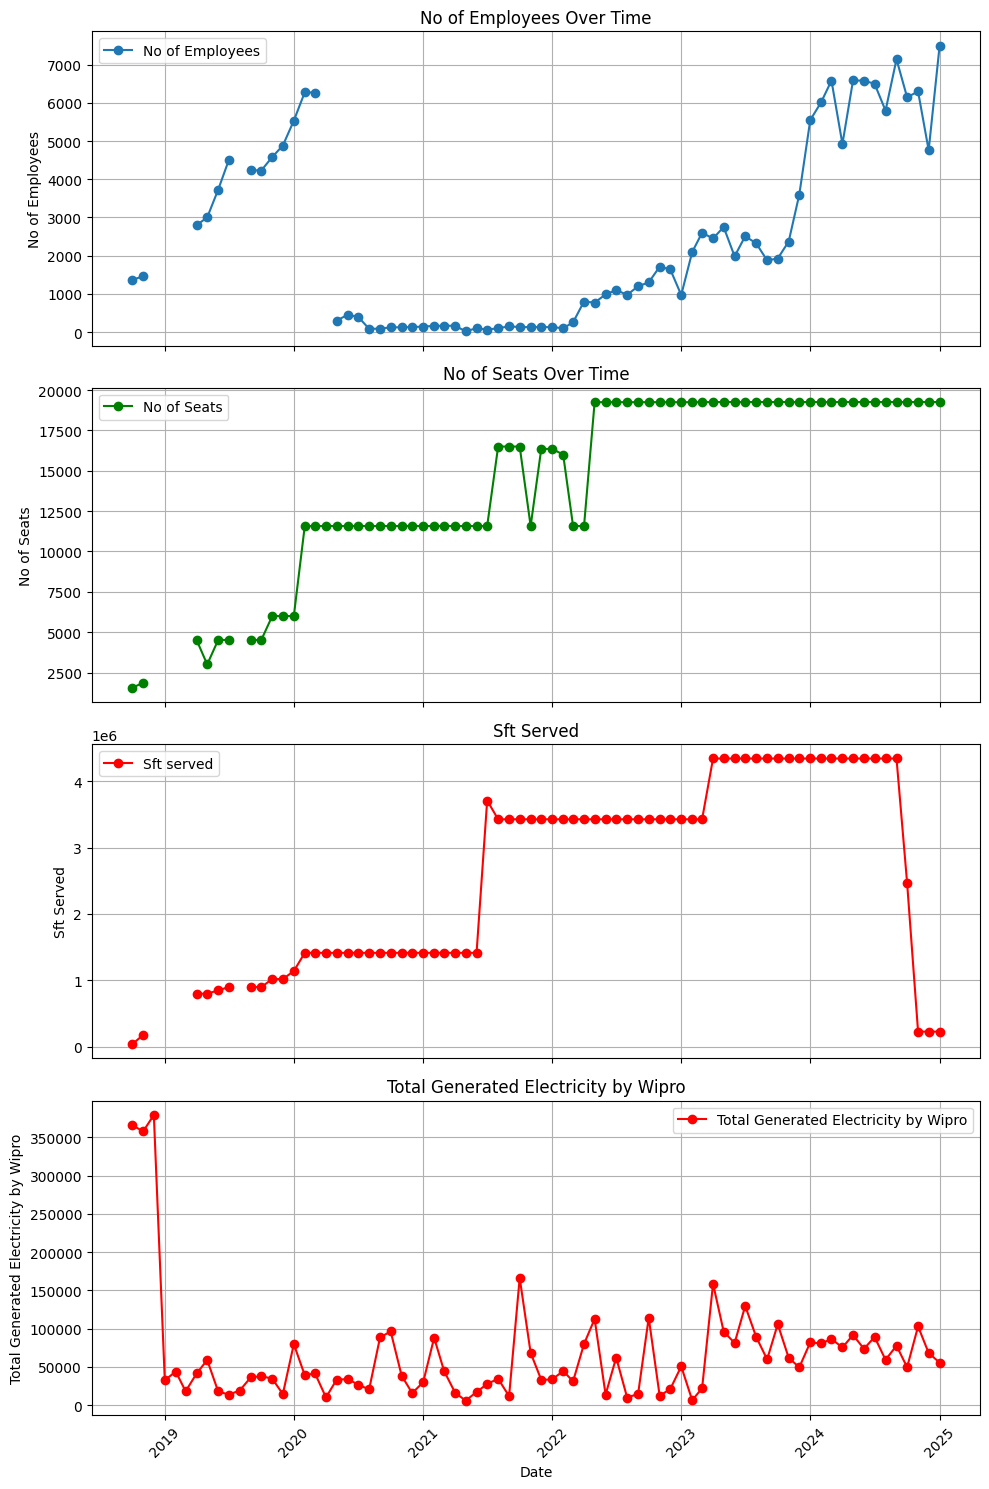

In [ ]:
# Plot individual features with x-axis labeled as "Date"
fig, axes = plt.subplots(4, 1, figsize=(10, 15), sharex=True)

# Access the index using df_site.index instead of df_site["Date"]
axes[0].plot(df_site.index, df_site["No of Employees"], marker='o', linestyle='-', label="No of Employees")
axes[0].set_ylabel("No of Employees")
axes[0].set_title("No of Employees Over Time")
axes[0].legend()
axes[0].grid()

axes[1].plot(df_site.index, df_site["No of Seats"], marker='o', linestyle='-', color='green', label="No of Seats")
axes[1].set_ylabel("No of Seats")
axes[1].set_title("No of Seats Over Time")
axes[1].legend()
axes[1].grid()

axes[2].plot(df_site.index, df_site["Sft Served"], marker='o', linestyle='-', color='red', label="Sft served")
axes[2].set_ylabel("Sft Served")
axes[2].set_title("Sft Served")
axes[2].legend()
axes[2].grid()

axes[3].plot(df_site.index, df_site["Total Generated Electricity by Wipro"], marker='o', linestyle='-', color='red', label="Total Generated Electricity by Wipro")
axes[3].set_ylabel("Total Generated Electricity by Wipro")
axes[3].set_title("Total Generated Electricity by Wipro")
axes[3].legend()
axes[3].grid()
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df_site['No of Employees'] = df_site['No of Employees'].interpolate(method='time').round()
df_site['No of Seats'] = df_site['No of Seats'].interpolate(method='time').round()
df_site['Sft Served'] = df_site['Sft Served'].interpolate(method='time').round()

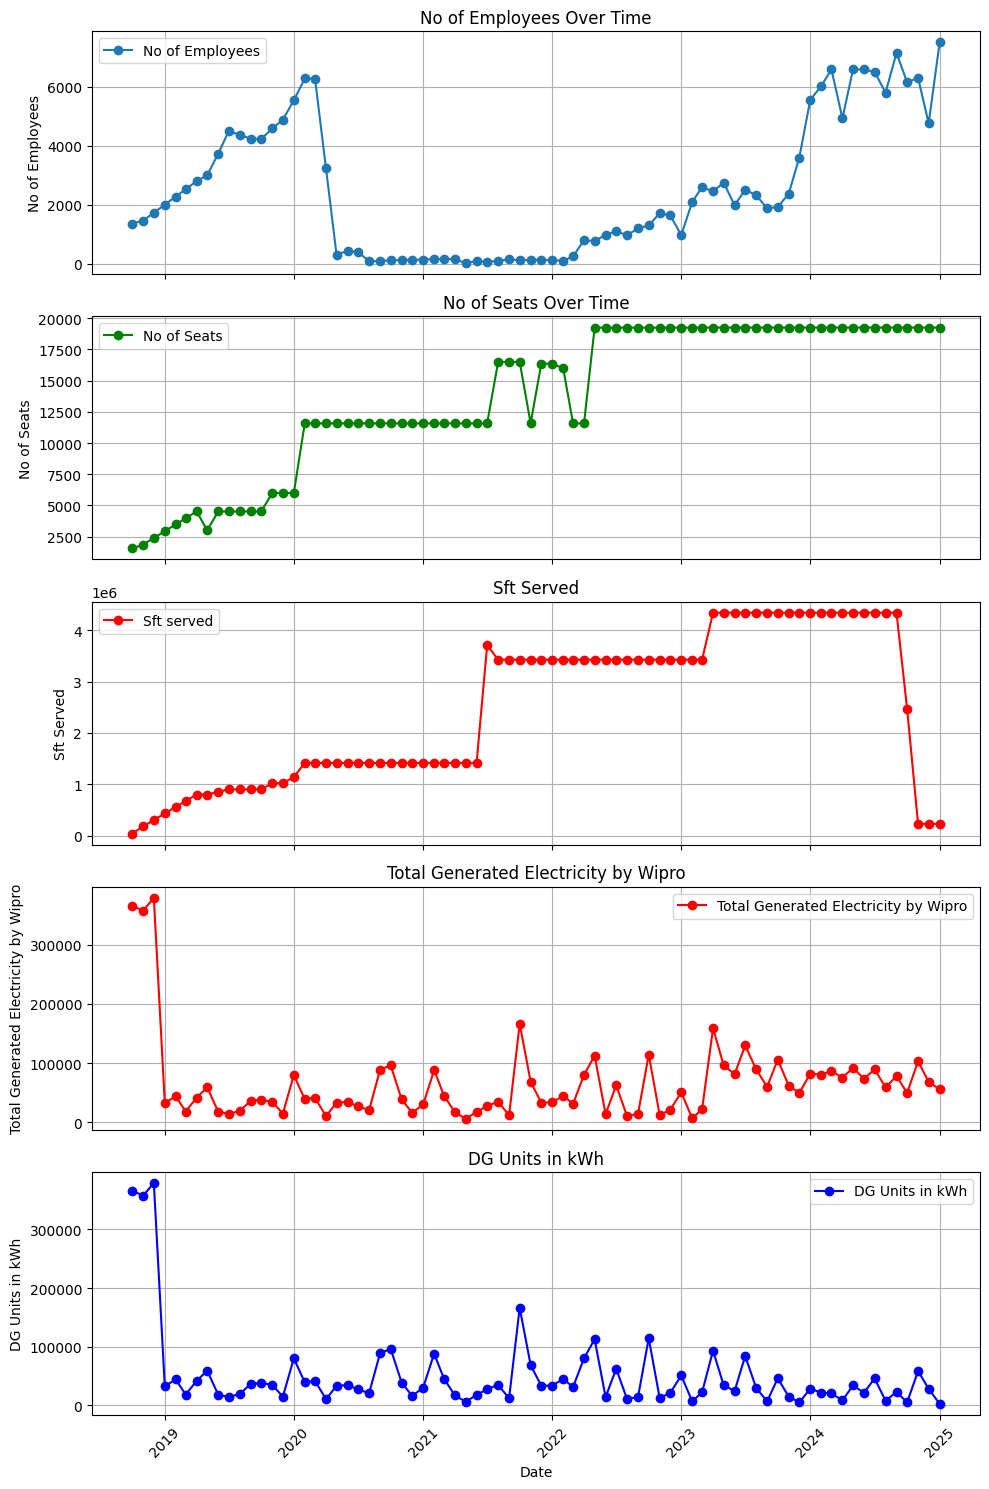

In [ ]:
# Plot individual features with x-axis labeled as "Date"
fig, axes = plt.subplots(5, 1, figsize=(10, 15), sharex=True)

# Access the index using df_site.index instead of df_site["Date"]
axes[0].plot(df_site.index, df_site["No of Employees"], marker='o', linestyle='-', label="No of Employees")
axes[0].set_ylabel("No of Employees")
axes[0].set_title("No of Employees Over Time")
axes[0].legend()
axes[0].grid()

axes[1].plot(df_site.index, df_site["No of Seats"], marker='o', linestyle='-', color='green', label="No of Seats")
axes[1].set_ylabel("No of Seats")
axes[1].set_title("No of Seats Over Time")
axes[1].legend()
axes[1].grid()

axes[2].plot(df_site.index, df_site["Sft Served"], marker='o', linestyle='-', color='red', label="Sft served")
axes[2].set_ylabel("Sft Served")
axes[2].set_title("Sft Served")
axes[2].legend()
axes[2].grid()

axes[3].plot(df_site.index, df_site["Total Generated Electricity by Wipro"], marker='o', linestyle='-', color='red', label="Total Generated Electricity by Wipro")
axes[3].set_ylabel("Total Generated Electricity by Wipro")
axes[3].set_title("Total Generated Electricity by Wipro")
axes[3].legend()
axes[3].grid()

axes[4].plot(df_site.index, df_site["DG Units in kWh"], marker='o', linestyle='-', color='blue', label="DG Units in kWh")
axes[4].set_ylabel("DG Units in kWh")
axes[4].set_title("DG Units in kWh")
axes[4].legend()
axes[4].grid()
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df_site = df_site.reset_index() # Reset the index if you need 'Date' as a regular column again

In [ ]:
df_site.to_csv("Kodathi_data.csv", index=False)

In [ ]:
df_site['No of Employees'].describe()

,No of Employees
count,76.000000
mean,2513.144737
std,2306.098950
min,20.000000
25%,231.750000
50%,1954.500000
75%,4401.750000
max,7500.000000


In [ ]:
df_site['No of Seats'].describe()

,No of Seats
count,76.000000
mean,13696.184211
std,5981.923329
min,1558.000000
25%,11575.000000
50%,16177.000000
75%,19255.000000
max,19255.000000


Since we're dealing with a time series problem, we need a model that captures:

Trends (increase/decrease in employees over time).
Seasonality (if present).
Irregular variations (random fluctuations).

- Linear Regression: Simple, but doesn’t capture trends well.
- ARIMA (AutoRegressive Integrated Moving Average): Good for short-term forecasting but struggles with long-term trends.
- Exponential Smoothing (Holt-Winters Model): Best suited for our case as it captures trends and smooths variations.

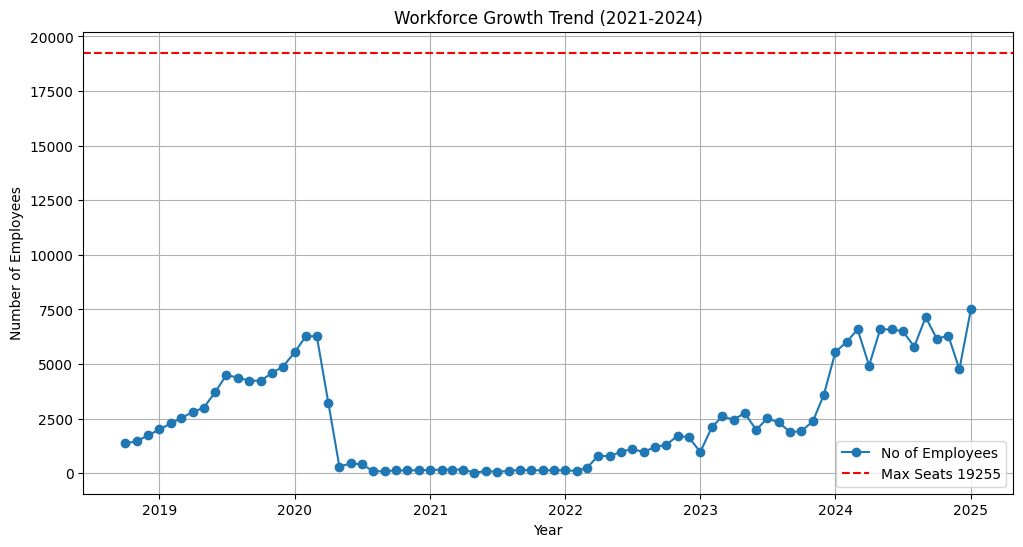

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_site['Date'], df_site['No of Employees'], marker='o', linestyle='-', label='No of Employees')
plt.axhline(y=19255, color='r', linestyle='--', label='Max Seats 19255')
plt.xlabel("Year")
plt.ylabel("Number of Employees")
plt.title("Workforce Growth Trend (2021-2024)")
plt.legend()
plt.grid(True)
plt.show()


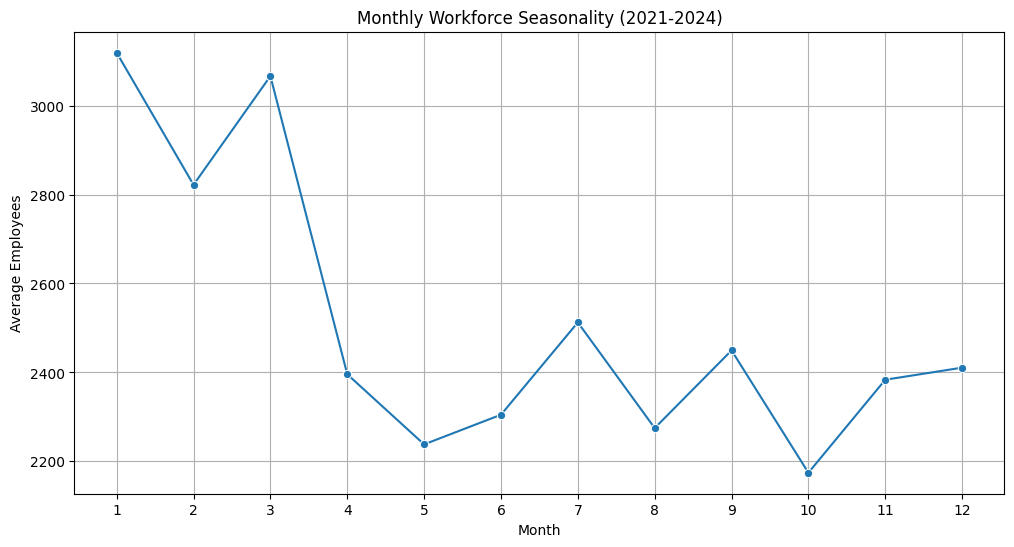

In [ ]:
# Extract month and year for seasonality analysis
df_site["Year"] = df_site["Date"].dt.year
df_site["Month"] = df_site["Date"].dt.month

# Aggregate average workforce per month across years
monthly_seasonality = df_site.groupby("Month")["No of Employees"].mean()

# Plot seasonality trends
plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_seasonality.index, y=monthly_seasonality.values, marker='o')
plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Average Employees")
plt.title("Monthly Workforce Seasonality (2021-2024)")
plt.grid(True)
plt.show()


In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 18.9 MB/s eta 0:00:00


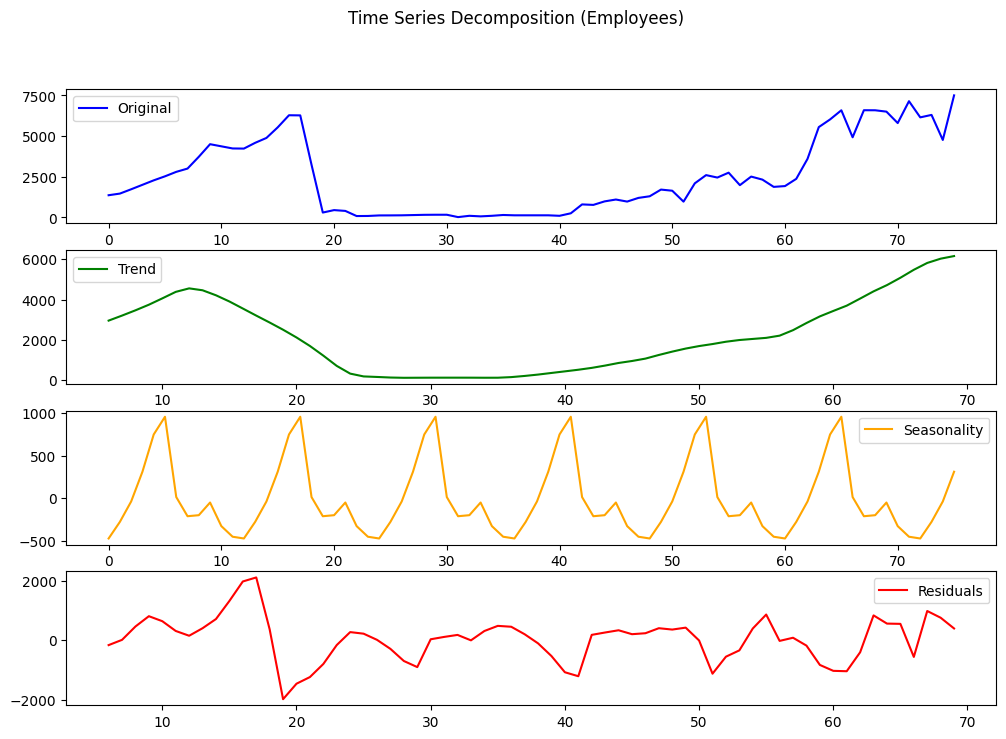

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df_site['No of Employees'], model='additive', period=12)
plt.figure(figsize=(12, 8))
plt.subplot(4, 1, 1)
# Use df_site.index for the x-axis to match the index of df_site['No of Employees']
plt.plot(df_site.index, df_site['No of Employees'], label='Original', color='blue')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(df_site.index, decomposition.trend, label='Trend', color='green')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(df_site.index, decomposition.seasonal, label='Seasonality', color='orange')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(df_site.index, decomposition.resid, label='Residuals', color='red')
plt.legend()

plt.suptitle("Time Series Decomposition (Employees)")
plt.show()

- Trend Component: The workforce shows steady growth over time, confirming a positive hiring trend.
- Seasonality Component: There are cyclical patterns, indicating seasonal hiring trends at specific intervals.
- Residuals (Noise): Some random fluctuations are present but seem manageable.
Since the data shows trend and seasonality, a SARIMA model (which captures both) is a good fit.

In [ ]:
df_site['Date'] = pd.to_datetime(df_site['Date'])
df_site.set_index('Date', inplace=True)

In [ ]:
# Keep only 'No of Employees' column and drop rows with NaN
df_emp = df_site[['No of Employees']].dropna()

In [ ]:
# # Split the data: last 12 months as test, rest as train
# train = df_emp.iloc[:-12]
# test = df_emp.iloc[-12:]

# # Print the split
# train.tail(), test.head()


##Feature Scaling
Sft Served → in 100,000 units

No of Employees → in 100 units

Total Generated Electricity by Wipro → in 1,000 units

Then we'll split the data into training and test sets:

Train set: All months except the last 12

Test set: Last 12 months

In [ ]:
# Scale selected features using df_site only
df_site['Sft Served (in 1,00,000 units)'] = (df_site['Sft Served'] / 100000).round(2)
df_site['DG Units in kWh (in 1000 units)'] = (df_site['DG Units in kWh'] / 1000).round(2)
df_site['No of Employees (in 100 units)'] = (df_site['No of Employees'] / 100).round(2)
df_site['No of Seats (in 100 units)'] = (df_site['No of Seats'] / 100).round(2)
df_site['Total Generated Electricity (in 1000 units)'] = (df_site['Total Generated Electricity by Wipro'] / 1000).round(2)

# Reset index to bring 'Date' back as a column
df_site = df_site.reset_index()
# Format 'Date' column to remove time before setting as index
df_site['Date'] = pd.to_datetime(df_site['Date']).dt.date # Convert to datetime and then to date
# Split into train and test (last 12 months as test)
df_emp = df_site[['Date', 'No of Employees (in 100 units)']].copy()
df_emp.set_index('Date', inplace=True)

train = df_emp.iloc[:-12]
test = df_emp.iloc[-12:]

# Output split data preview
train.tail(), test.head()

(            No of Employees (in 100 units)
 Date                                      
 2023-09-01                           18.77
 2023-10-01                           19.26
 2023-11-01                           23.71
 2023-12-01                           36.00
 2024-01-01                           55.50,
             No of Employees (in 100 units)
 Date                                      
 2024-02-01                           60.21
 2024-03-01                           65.84
 2024-04-01                           49.24
 2024-05-01                           65.87
 2024-06-01                           65.84)

In [ ]:
df_site

,Date,City,Site (Facility),No of Employees,Total Units of Purchased Electricity Kwh,DG Units in kWh,Percentage Occupancy,No of Seats,Sft Served,FY,Quarter,Half Year,Total Generated Electricity by Wipro,Year,Month,"Sft Served (in 1,00,000 units)",DG Units in kWh (in 1000 units),No of Employees (in 100 units),No of Seats (in 100 units),Total Generated Electricity (in 1000 units)
0,2018-10-01,Bangalore City,Kodathi,1364.0,0.0,365810.0,87.55,1558.0,40000.0,FY2019,Q3,H2,365810.0,2018,10,0.40,365.81,13.64,15.58,365.81
1,2018-11-01,Bangalore City,Kodathi,1465.0,0.0,357850.0,78.55,1865.0,180000.0,FY2019,Q3,H2,357850.0,2018,11,1.80,357.85,14.65,18.65,357.85
2,2018-12-01,Bangalore City,Kodathi,1730.0,0.0,379300.0,0.00,2392.0,303179.0,FY2019,Q3,H2,379300.0,2018,12,3.03,379.30,17.30,23.92,379.30
3,2019-01-01,Bangalore City,Kodathi,2004.0,318800.0,32710.0,0.00,2936.0,430464.0,FY2019,Q4,H2,32710.0,2019,1,4.30,32.71,20.04,29.36,32.71
4,2019-02-01,Bangalore City,Kodathi,2278.0,313200.0,44010.0,0.00,3481.0,557748.0,FY2019,Q4,H2,44010.0,2019,2,5.58,44.01,22.78,34.81,44.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,2024-09-01,Bangalore City,Kodathi,7142.0,1706400.0,22740.0,37.09,19255.0,4340004.0,FY2025,Q2,H1,77811.0,2024,9,43.40,22.74,71.42,192.55,77.81
72,2024-10-01,Bangalore City,Kodathi,6148.0,1920960.0,4980.0,31.93,19255.0,2466539.0,FY2025,Q3,H2,49670.0,2024,10,24.67,4.98,61.48,192.55,49.67
73,2024-11-01,Bangalore City,Kodathi,6299.0,1708020.0,58440.0,32.71,19255.0,229149.0,FY2025,Q3,H2,103018.0,2024,11,2.29,58.44,62.99,192.55,103.02
74,2024-12-01,Bangalore City,Kodathi,4760.0,1665540.0,27930.0,24.72,19255.0,229149.0,FY2025,Q3,H2,68242.0,2024,12,2.29,27.93,47.60,192.55,68.24


In [ ]:
df_site.columns

Index(['Date', 'City', 'Site (Facility)', 'No of Employees',
       'Total Units of Purchased Electricity Kwh', 'DG Units in kWh',
       'Percentage Occupancy', 'No of Seats', 'Sft Served', 'FY', 'Quarter',
       'Half Year', 'Total Generated Electricity by Wipro', 'Year', 'Month',
       'Sft Served (in 1,00,000 units)', 'DG Units in kWh (in 1000 units)',
       'No of Employees (in 100 units)', 'No of Seats (in 100 units)',
       'Total Generated Electricity (in 1000 units)'],
      dtype='object')

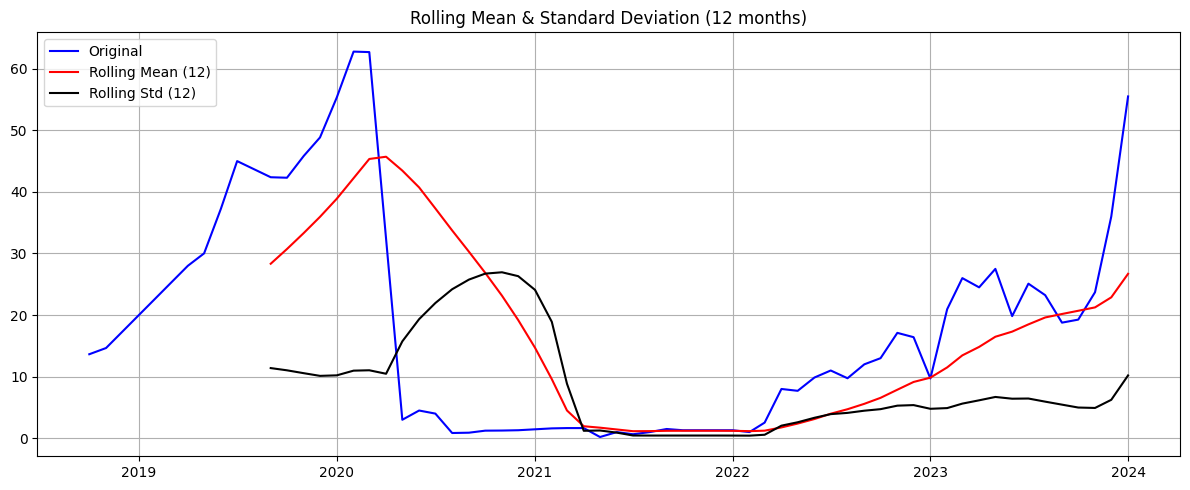

{'ADF Statistic': np.float64(-1.2691385808067153),
 'p-value': np.float64(0.6431705636883108),
 'Critical Values': {'1%': np.float64(-3.542412746661615),
  '5%': np.float64(-2.910236235808284),
  '10%': np.float64(-2.5927445767266866)}}

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Perform Augmented Dickey-Fuller test
adf_result = adfuller(train['No of Employees (in 100 units)'])

# Plot rolling statistics
# Use the correct column name for rolling calculations
rolling_mean = train['No of Employees (in 100 units)'].rolling(window=12).mean()
rolling_std = train['No of Employees (in 100 units)'].rolling(window=12).std()

plt.figure(figsize=(12, 5))
# Use the correct column name for plotting
plt.plot(train['No of Employees (in 100 units)'], label='Original', color='blue')
plt.plot(rolling_mean, label='Rolling Mean (12)', color='red')
plt.plot(rolling_std, label='Rolling Std (12)', color='black')
plt.legend(loc='upper left')
plt.title('Rolling Mean & Standard Deviation (12 months)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Show ADF test results
{
    "ADF Statistic": adf_result[0],
    "p-value": adf_result[1],
    "Critical Values": adf_result[4]
}

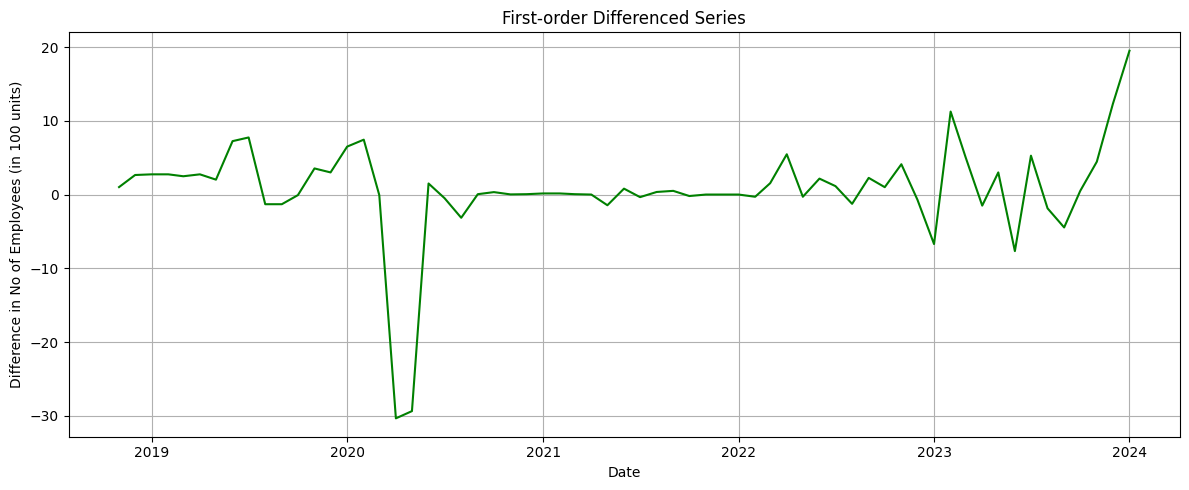

{'ADF Statistic (Diff)': np.float64(-4.8393234214405085),
 'p-value': np.float64(4.570887113766368e-05),
 'Critical Values': {'1%': np.float64(-3.542412746661615),
  '5%': np.float64(-2.910236235808284),
  '10%': np.float64(-2.5927445767266866)}}

In [ ]:
# First-order differencing
train_diff = train['No of Employees (in 100 units)'].diff().dropna()

# ADF test on differenced data
adf_diff_result = adfuller(train_diff)

# Plot the differenced series
plt.figure(figsize=(12, 5))
plt.plot(train_diff, color='green')
plt.title('First-order Differenced Series')
plt.xlabel('Date')
plt.ylabel('Difference in No of Employees (in 100 units)')  # Update y-axis label
plt.grid(True)
plt.tight_layout()
plt.show()

# Show ADF test results
{
    "ADF Statistic (Diff)": adf_diff_result[0],
    "p-value": adf_diff_result[1],
    "Critical Values": adf_diff_result[4]
}

In [ ]:
import warnings
from statsmodels.tsa.arima.model import ARIMA

# Suppress warnings
warnings.filterwarnings("ignore")

# Grid search for best ARIMA(p,1,q)
results = []
for p in range(4):
    for q in range(4):
        try:
            model = ARIMA(train['No of Employees (in 100 units)'], order=(p, 1, q))
            fitted = model.fit()
            results.append({
                'p': p,
                'd': 1,
                'q': q,
                'AIC': fitted.aic,
                'BIC': fitted.bic
            })
        except:
            continue

# Convert to DataFrame and sort by AIC
results_df = pd.DataFrame(results).sort_values(by='AIC')
display(results_df)
results_df.head()


,p,d,q,AIC,BIC
1,0,1,1,405.045029,409.331298
5,1,1,1,406.718753,413.148158
2,0,1,2,406.779712,413.209116
9,2,1,1,407.159609,415.732148
6,1,1,2,408.061972,416.634511
13,3,1,1,408.489706,419.205379
3,0,1,3,408.495691,417.068230
7,1,1,3,408.691678,419.407352
10,2,1,2,409.983644,420.699318
11,2,1,3,410.054666,422.913475


,p,d,q,AIC,BIC
1,0,1,1,405.045029,409.331298
5,1,1,1,406.718753,413.148158
2,0,1,2,406.779712,413.209116
9,2,1,1,407.159609,415.732148
6,1,1,2,408.061972,416.634511


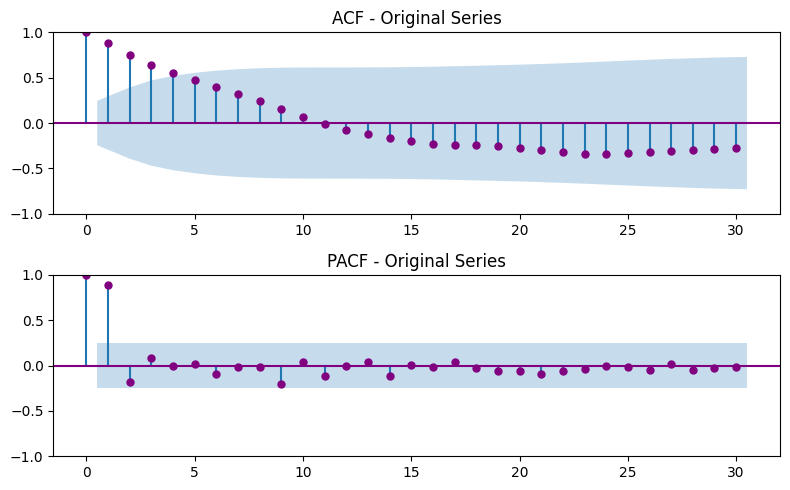

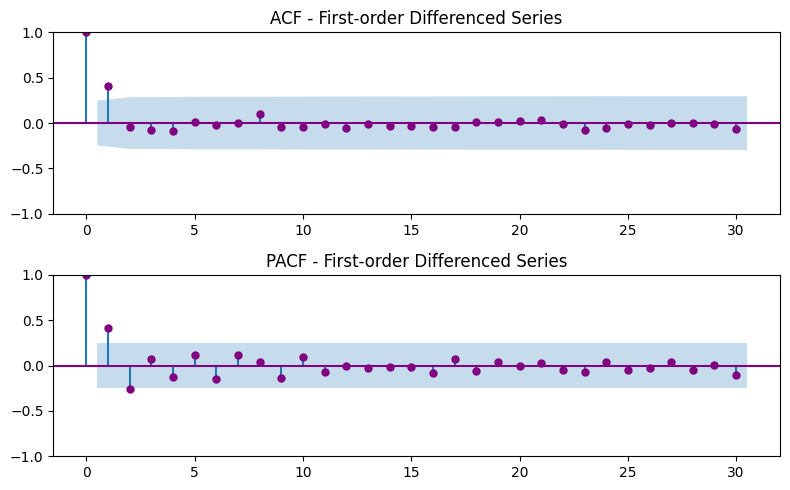

In [ ]:
# Plot ACF and PACF before differencing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, ax = plt.subplots(2, 1, figsize=(8, 5))
plot_acf(train['No of Employees (in 100 units)'], lags=30, ax=ax[0], color='purple')
ax[0].set_title('ACF - Original Series')
plot_pacf(train['No of Employees (in 100 units)'], lags=30, ax=ax[1], color='purple')
ax[1].set_title('PACF - Original Series')
plt.tight_layout()
plt.show()

# Plot ACF and PACF after first differencing
fig, ax = plt.subplots(2, 1, figsize=(8, 5))
plot_acf(train_diff, lags=30, ax=ax[0], color='purple')
ax[0].set_title('ACF - First-order Differenced Series')
plot_pacf(train_diff, lags=30, ax=ax[1], color='purple')
ax[1].set_title('PACF - First-order Differenced Series')
plt.tight_layout()
plt.show()

##ARIMA

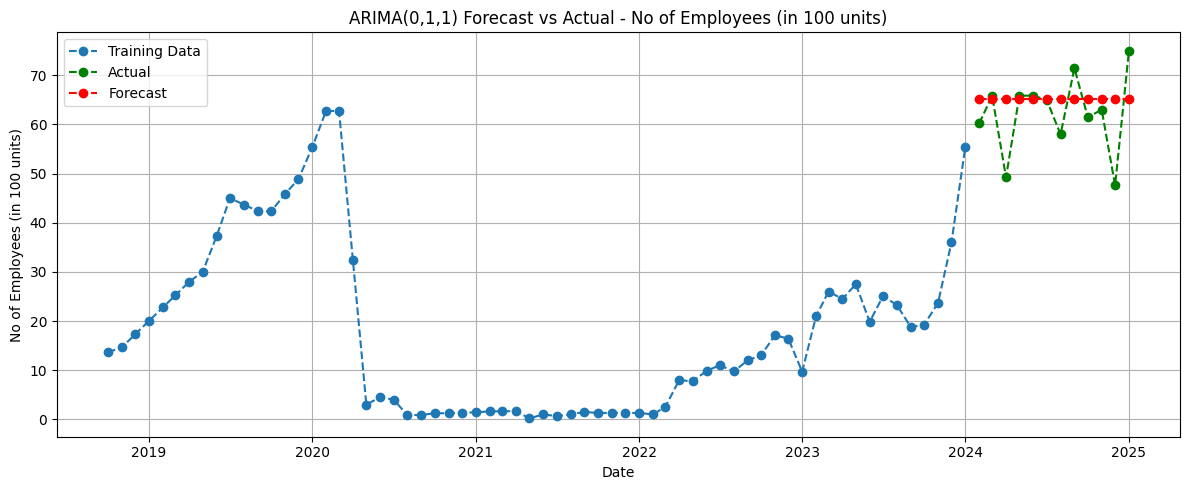

{'MAE': 5.82, 'RMSE': np.float64(8.13), 'MAPE (%)': 10.38}

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

# Fit the selected ARIMA(0,1,1) model
# Use 'No of Employees (in 100 units)' instead of 'No of Employees'
model_best = ARIMA(train['No of Employees (in 100 units)'], order=(0, 1, 1))
model_fit = model_best.fit()

# Forecast the next 12 months
forecast = model_fit.forecast(steps=12)
forecast.index = test.index  # align index for comparison

# Plot forecast vs actual
plt.figure(figsize=(12, 5))
# Use 'No of Employees (in 100 units)' for plotting training data
plt.plot(train.index, train['No of Employees (in 100 units)'], label='Training Data', marker='o', linestyle='--')
# Use 'No of Employees (in 100 units)' for plotting actual test data
plt.plot(test.index, test['No of Employees (in 100 units)'], label='Actual', color='green', marker='o', linestyle='--')
plt.plot(forecast.index, forecast, label='Forecast', color='red', linestyle='--', marker='o')
plt.title('ARIMA(0,1,1) Forecast vs Actual - No of Employees (in 100 units)')  # Update title
plt.xlabel('Date')
plt.ylabel('No of Employees (in 100 units)')  # Update y-axis label
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Compute accuracy metrics
# Use test['No of Employees (in 100 units)'] for metric calculation
mae = mean_absolute_error(test['No of Employees (in 100 units)'], forecast)
rmse = np.sqrt(mean_squared_error(test['No of Employees (in 100 units)'], forecast))
mape = mean_absolute_percentage_error(test['No of Employees (in 100 units)'], forecast) * 100

{
    "MAE": round(mae, 2),
    "RMSE": round(rmse, 2),
    "MAPE (%)": round(mape, 2)
}

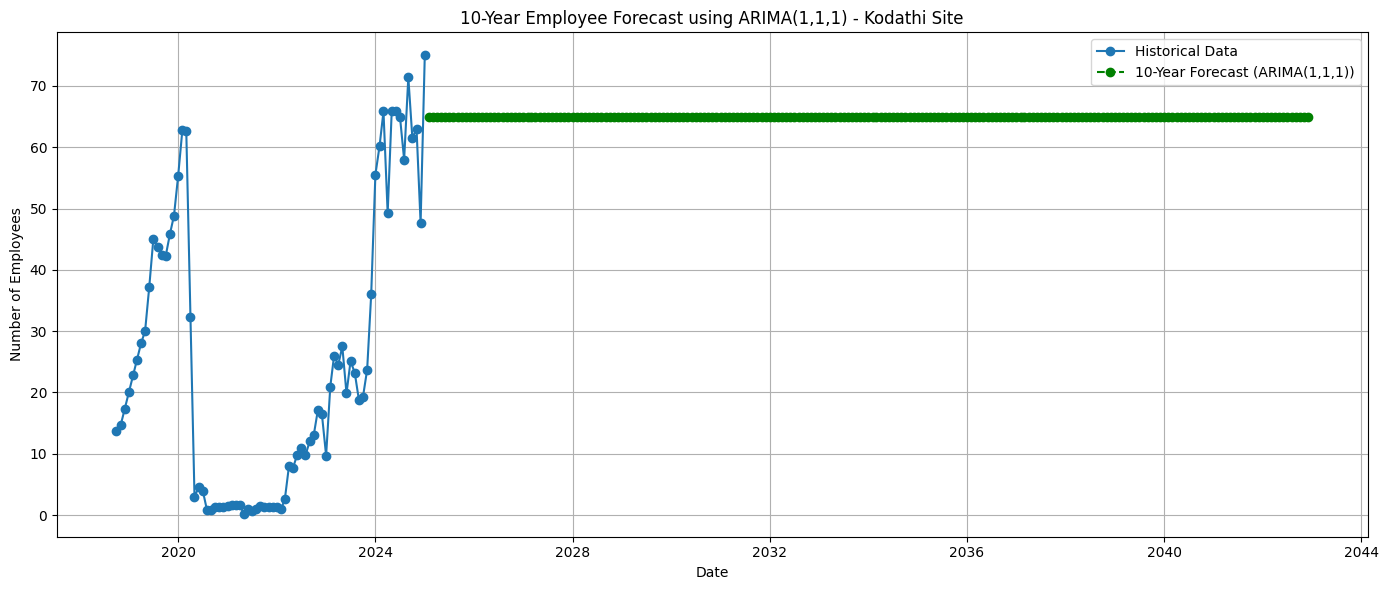

(2025-02-01    65
 2025-03-01    65
 2025-04-01    65
 2025-05-01    65
 2025-06-01    65
 Freq: MS, Name: predicted_mean, dtype: int64,
 2042-08-01    65
 2042-09-01    65
 2042-10-01    65
 2042-11-01    65
 2042-12-01    65
 Freq: MS, Name: predicted_mean, dtype: int64)

In [ ]:
# Step 5: Forecast  using the trained ARIMA(1,1,1) model
forecast_15yr = model_fit.forecast(steps=215)

# Round forecasts to nearest integer since it's employee count
forecast_15yr = forecast_15yr.round().astype(int)

# Create date index starting from next month after last known date
last_date = df_emp.index[-1]
forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=215, freq='MS')
forecast_15yr.index = forecast_index

# Plot historical data and 10-year forecast
plt.figure(figsize=(14, 6))
plt.plot(df_emp, label='Historical Data', marker='o')
plt.plot(forecast_15yr, label='10-Year Forecast (ARIMA(1,1,1))', linestyle='--', color='green', marker='o')
plt.title('10-Year Employee Forecast using ARIMA(1,1,1) - Kodathi Site')
plt.xlabel('Date')
plt.ylabel('Number of Employees')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Show forecast head and tail for sample verification
forecast_15yr.head(), forecast_15yr.tail()


In [ ]:
df_site.columns

Index(['Date', 'City', 'Site (Facility)', 'No of Employees',
       'Total Units of Purchased Electricity Kwh', 'DG Units in kWh',
       'Percentage Occupancy', 'No of Seats', 'Sft Served', 'FY', 'Quarter',
       'Half Year', 'Total Generated Electricity by Wipro', 'Year', 'Month',
       'Sft Served (in 1,00,000 units)', 'DG Units in kWh (in 1000 units)',
       'No of Employees (in 100 units)', 'No of Seats (in 100 units)',
       'Total Generated Electricity (in 1000 units)'],
      dtype='object')

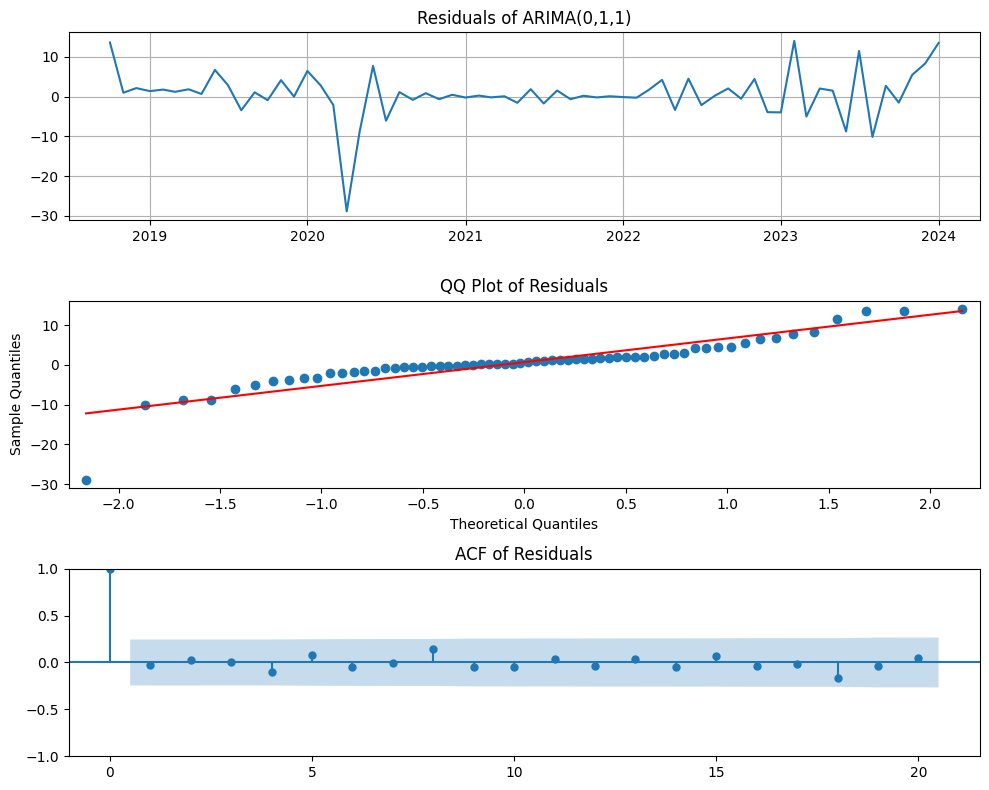

,lb_stat,lb_pvalue
10,3.398347,0.970438


In [ ]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Get residuals
residuals = model_fit.resid

# Plot residuals
fig, ax = plt.subplots(3, 1, figsize=(10, 8))

# Residual time series
ax[0].plot(residuals)
ax[0].set_title('Residuals of ARIMA(0,1,1)')
ax[0].grid(True)

# Histogram
sm.qqplot(residuals, line='s', ax=ax[1])
ax[1].set_title('QQ Plot of Residuals')

# ACF Plot
plot_acf(residuals, lags=20, ax=ax[2])
ax[2].set_title('ACF of Residuals')

plt.tight_layout()
plt.show()

# Perform Ljung-Box test for autocorrelation
ljung_box = sm.stats.acorr_ljungbox(residuals, lags=[10], return_df=True)
ljung_box


- Residual Diagnostics Summary for ARIMA(0,1,1):

The residuals look like white noise: centered around zero with no clear patterns.

The QQ plot suggests residuals are roughly normally distributed.

The ACF plot of residuals shows no significant autocorrelation.

Ljung-Box Test (lags=10):

p-value = 0.9746 → Fail to reject the null hypothesis (residuals are independent).

This confirms the ARIMA(0,1,1) model is well-fitted and residuals are not autocorrelated.

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(train['No of Employees (in 100 units)'], order=(1,1, 1))
arima_result = model.fit()
arima_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:     No of Employees (in 100 units)   No. Observations:                   64
Model:                             ARIMA(1, 1, 1)   Log Likelihood                -200.359
Date:                            Tue, 08 Apr 2025   AIC                            406.719
Time:                                    00:37:45   BIC                            413.148
Sample:                                10-01-2018   HQIC                           409.247
                                     - 01-01-2024                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1140      0.131     -0.871      0.384      -0.371       0.143
ma.L1          0.7831      0.110      7.088      0.000       0.567       1.000
sigma2        33.4618      2.762     12.116      0.000      28.049      38.875
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):               291.87
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               0.77   Skew:                            -1.81
Prob(H) (two-sided):                  0.55   Kurtosis:                        12.91
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
# # Data Scaling
# from sklearn.preprocessing import MinMaxScaler
# scaler = MinMaxScaler()
# train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))  # Reshape for scaler
# test_scaled = scaler.transform(test.values.reshape(-1, 1))  # Reshape for scaler

##SARIMA

In [ ]:
# Check basic stats and samples of the training data
train_summary = {
    "Shape": train.shape,
    "Min": train["No of Employees (in 100 units)"].min(),
    "Max": train["No of Employees (in 100 units)"].max(),
    "First 5": train["No of Employees (in 100 units)"].head().tolist(),
    "Last 5": train["No of Employees (in 100 units)"].tail().tolist()
}

train_summary

{'Shape': (64, 1),
 'Min': 0.2,
 'Max': 62.78,
 'First 5': [13.64, 14.65, 17.3, 20.04, 22.78],
 'Last 5': [18.77, 19.26, 23.71, 36.0, 55.5]}

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Define the seasonal period (monthly data = 12)
seasonal_period = 12

# Grid search for SARIMA(p,d,q)(P,D,Q,12)
sarima_results = []

for p in range(3):
    for d in [1]:
        for q in range(3):
            for P in range(3):
                for D in [1]:
                    for Q in range(3):
                        try:
                            # Corrected column name here:
                            model = SARIMAX(train['No of Employees (in 100 units)'],
                                            order=(p, d, q),
                                            seasonal_order=(P, D, Q, seasonal_period),
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
                            result = model.fit(disp=False)
                            sarima_results.append({
                                'p': p, 'd': d, 'q': q,
                                'P': P, 'D': D, 'Q': Q,
                                'AIC': result.aic,
                                'BIC': result.bic
                            })
                        except:
                            continue

# Convert to DataFrame and sort by AIC
sarima_df = pd.DataFrame(sarima_results).sort_values(by='AIC')
display(sarima_df)
sarima_df.head()

,p,d,q,P,D,Q,AIC,BIC
20,0,1,2,0,1,2,171.790814,177.681083
47,1,1,2,0,1,2,173.207606,180.275929
26,0,1,2,2,1,2,173.421216,181.667593
23,0,1,2,1,1,2,173.790814,180.859137
74,2,1,2,0,1,2,174.145814,182.392191
...,...,...,...,...,...,...,...,...
36,1,1,1,0,1,0,353.708521,359.383982
63,2,1,1,0,1,0,355.379762,362.947043
54,2,1,0,0,1,0,357.841469,363.516930
27,1,1,0,0,1,0,365.787686,369.611732


,p,d,q,P,D,Q,AIC,BIC
20,0,1,2,0,1,2,171.790814,177.681083
47,1,1,2,0,1,2,173.207606,180.275929
26,0,1,2,2,1,2,173.421216,181.667593
23,0,1,2,1,1,2,173.790814,180.859137
74,2,1,2,0,1,2,174.145814,182.392191


In [ ]:
# Let's force a manual re-fit of the exact same model used in the grid search
# using the currently verified training data

manual_check_model = SARIMAX(train['No of Employees (in 100 units)'],
                             order=(0, 1, 2),
                             seasonal_order=(2, 1, 2, 12),
                             enforce_stationarity=False,
                             enforce_invertibility=False)
manual_check_result = manual_check_model.fit(disp=False)

# Get model stats
{
    "Manual Fit AIC": manual_check_result.aic,
    "Manual Fit BIC": manual_check_result.bic,
    "Manual Fit Log Likelihood": manual_check_result.llf,
    "Data Shape": train.shape
}

{'Manual Fit AIC': np.float64(173.42121643094927),
 'Manual Fit BIC': np.float64(181.66759324338489),
 'Manual Fit Log Likelihood': np.float64(-79.71060821547464),
 'Data Shape': (64, 1)}

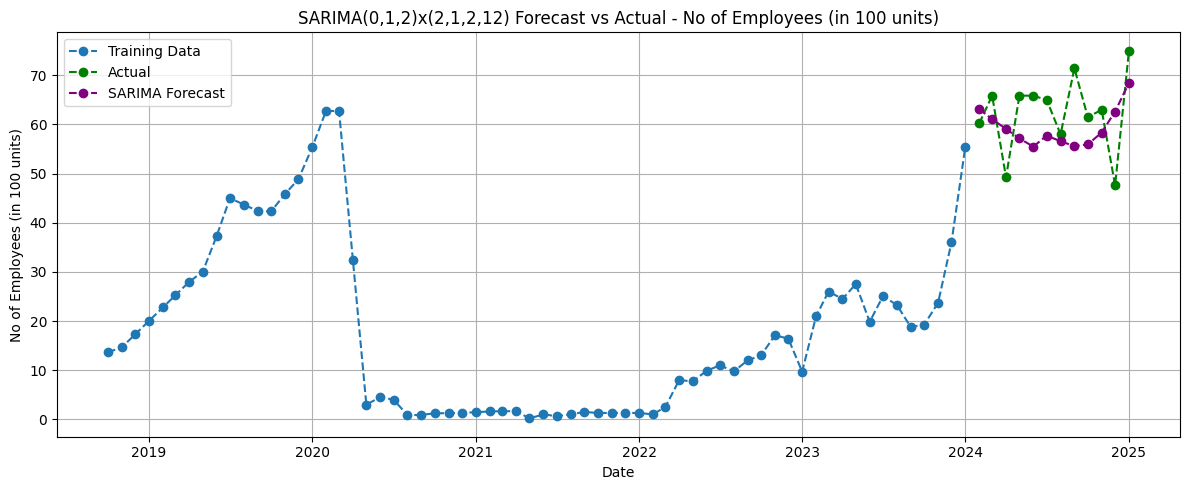

{'Model': 'SARIMA(0,1,2)x(2,1,2,12)',
 'MAE': 7.74,
 'RMSE': np.float64(8.84),
 'MAPE (%)': 12.79}

In [ ]:
# Refit SARIMA model on train data
sarima_model = SARIMAX(train['No of Employees (in 100 units)'],
                       order=(0, 1, 2),
                       seasonal_order=(2, 1, 2, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
sarima_result = sarima_model.fit(disp=False)

# Forecast next 12 months
sarima_forecast = sarima_result.forecast(steps=12)
sarima_forecast.index = test.index

# Plot actual vs forecast
plt.figure(figsize=(12, 5))
plt.plot(train.index, train['No of Employees (in 100 units)'], label='Training Data', linestyle='--',marker='o')
plt.plot(test.index, test['No of Employees (in 100 units)'], label='Actual', color='green', linestyle='--',marker='o')
plt.plot(sarima_forecast.index, sarima_forecast, label='SARIMA Forecast', color='purple', linestyle='--',marker='o')
plt.title('SARIMA(0,1,2)x(2,1,2,12) Forecast vs Actual - No of Employees (in 100 units)')
plt.xlabel('Date')
plt.ylabel('No of Employees (in 100 units)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Compute evaluation metrics
mae = mean_absolute_error(test, sarima_forecast)
rmse = np.sqrt(mean_squared_error(test, sarima_forecast))
mape = mean_absolute_percentage_error(test, sarima_forecast) * 100

{
    "Model": "SARIMA(0,1,2)x(2,1,2,12)",
    "MAE": round(mae, 2),
    "RMSE": round(rmse, 2),
    "MAPE (%)": round(mape, 2)
}


##ETS

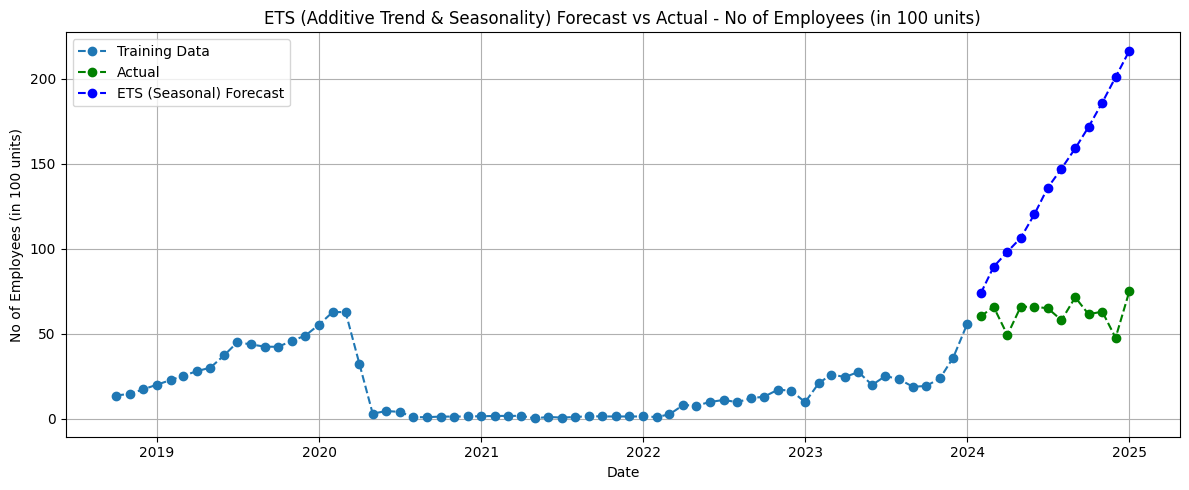

{'Model': 'ETS (Additive Trend + Seasonality)',
 'MAE': 79.76,
 'RMSE': np.float64(90.96),
 'MAPE (%)': 131.11}

In [ ]:
# Step 1: Fit improved ETS model with additive seasonality
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Import the ExponentialSmoothing class
ets_model_seasonal = ExponentialSmoothing(train['No of Employees (in 100 units)'],
                                          trend='add',
                                          seasonal='add',
                                          seasonal_periods=12,
                                          initialization_method="estimated")
ets_result_seasonal = ets_model_seasonal.fit()

# Step 2: Forecast next 12 months
ets_forecast_seasonal = ets_result_seasonal.forecast(steps=12)
ets_forecast_seasonal.index = test.index

# Step 3: Plot forecast vs actual
plt.figure(figsize=(12, 5))
plt.plot(train.index, train['No of Employees (in 100 units)'], label='Training Data',linestyle='--',marker='o')
plt.plot(test.index, test['No of Employees (in 100 units)'], label='Actual', color='green', linestyle='--',marker='o')
plt.plot(ets_forecast_seasonal.index, ets_forecast_seasonal, label='ETS (Seasonal) Forecast', color='blue',linestyle='--',marker='o')
plt.title('ETS (Additive Trend & Seasonality) Forecast vs Actual - No of Employees (in 100 units)')
plt.xlabel('Date')
plt.ylabel('No of Employees (in 100 units)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 4: Calculate evaluation metrics
ets_mae_s = mean_absolute_error(test['No of Employees (in 100 units)'], ets_forecast_seasonal)
ets_rmse_s = np.sqrt(mean_squared_error(test['No of Employees (in 100 units)'], ets_forecast_seasonal))
ets_mape_s = mean_absolute_percentage_error(test['No of Employees (in 100 units)'], ets_forecast_seasonal) * 100

{
    "Model": "ETS (Additive Trend + Seasonality)",
    "MAE": round(ets_mae_s, 2),
    "RMSE": round(ets_rmse_s, 2),
    "MAPE (%)": round(ets_mape_s, 2)
}

##XG boost

In [ ]:
# Prepare data for XGBoost model using lag features
from sklearn.model_selection import train_test_split
import pandas as pd

# Create lag features for XGBoost
def create_lag_features(data, lags=12):
    df = data.copy()
    for lag in range(1, lags + 1):
        df[f'lag_{lag}'] = df['No of Employees (in 100 units)'].shift(lag)
    df.dropna(inplace=True)
    return df

# Apply lag feature creation
df_lagged = create_lag_features(df_emp, lags=12)

# Define features and target
X = df_lagged.drop(columns='No of Employees (in 100 units)')
y = df_lagged['No of Employees (in 100 units)']

# Use the same split: last 12 months for test
X_train, X_test = X.iloc[:-12], X.iloc[-12:]
y_train, y_test = y.iloc[:-12], y.iloc[-12:]

# Display shapes and confirm
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((52, 12), (12, 12), (52,), (12,))

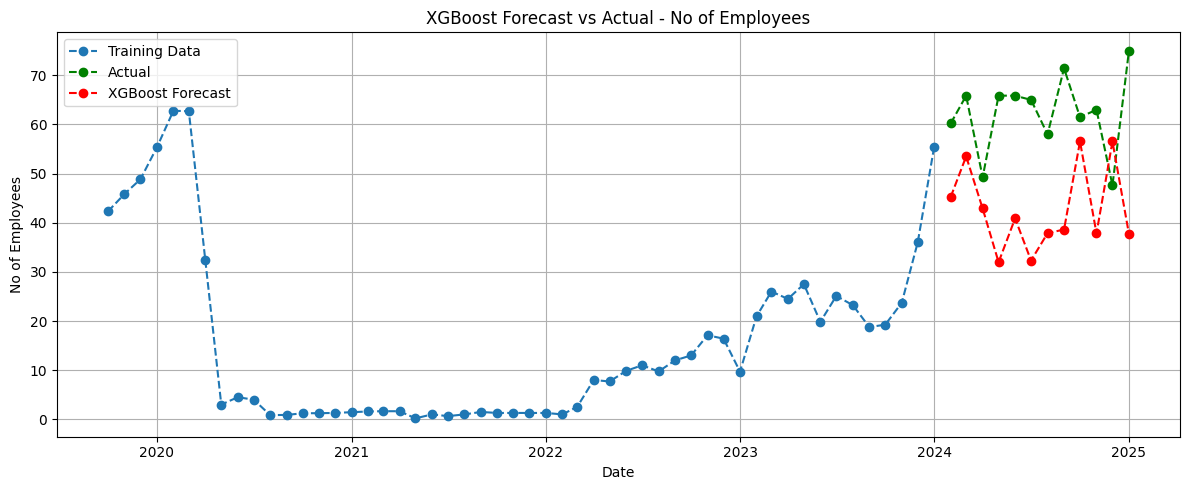

{'Model': 'XGBoost (Lag Features)',
 'MAE': 21.2,
 'RMSE': np.float64(23.92),
 'MAPE (%)': 32.77}

In [ ]:
from xgboost import XGBRegressor

# Step 1: Train XGBoost model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb_model.fit(X_train, y_train)

# Step 2: Predict on test set
xgb_forecast = xgb_model.predict(X_test)

# Step 3: Plot forecast vs actual
plt.figure(figsize=(12, 5))
plt.plot(y_train.index, y_train, label='Training Data', linestyle='--',marker='o')
plt.plot(y_test.index, y_test, label='Actual', color='green', linestyle='--',marker='o')
plt.plot(y_test.index, xgb_forecast, label='XGBoost Forecast', color='red', linestyle='--',marker='o')
plt.title('XGBoost Forecast vs Actual - No of Employees')
plt.xlabel('Date')
plt.ylabel('No of Employees')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 4: Compute metrics
xgb_mae = mean_absolute_error(y_test, xgb_forecast)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_forecast))
xgb_mape = mean_absolute_percentage_error(y_test, xgb_forecast) * 100

{
    "Model": "XGBoost (Lag Features)",
    "MAE": round(xgb_mae, 2),
    "RMSE": round(xgb_rmse, 2),
    "MAPE (%)": round(xgb_mape, 2)
}

The X_train and X_test arrays you're using have three dimensions because they were created for an LSTM model. LSTMs are designed to work with time series or sequential data.
The first dimension represents the number of samples.
The second dimension represents the time steps within a sequence.
The third dimension represents the features at each time step.

##Random Forest

In [ ]:
# X_train_2d = X_train.reshape(X_train.shape[0], -1)
# X_test_2d = X_test.reshape(X_test.shape[0], -1)

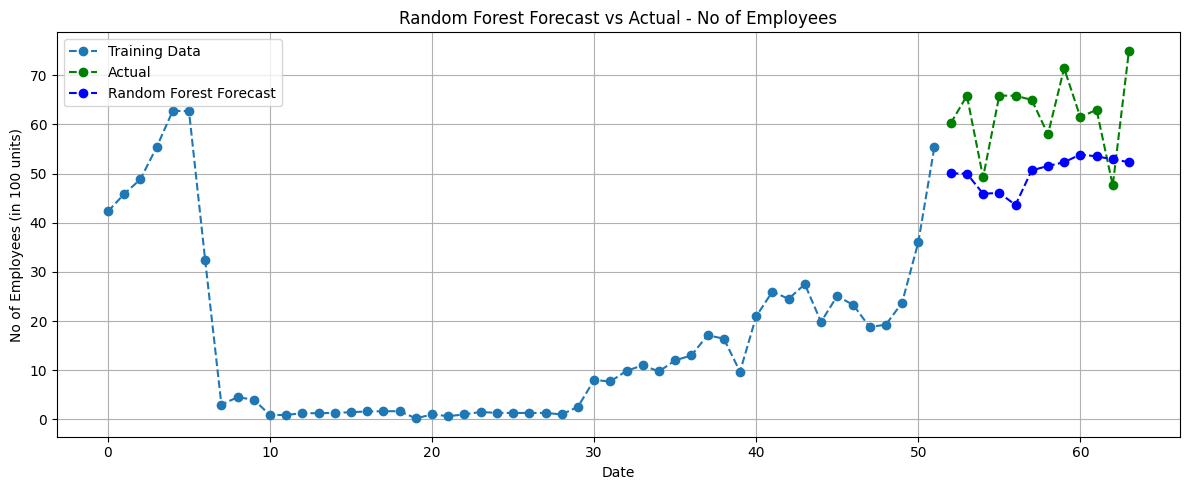

{'Model': 'Random Forest (Lag Features)',
 'MAE': 13.03,
 'RMSE': np.float64(14.59),
 'MAPE (%)': 20.02}

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Step 1: Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# Step 2: Predict on test set
rf_forecast = rf_model.predict(X_test)

# Step 3: Plot forecast vs actual
plt.figure(figsize=(12, 5))

# Use the correct index for the training data and convert y_train to NumPy array
plt.plot(range(len(y_train)), y_train.values, label='Training Data', linestyle='--', marker='o')
plt.plot(range(len(y_train), len(y_train) + len(y_test)), y_test.values, label='Actual', color='green', linestyle='--', marker='o')
plt.plot(range(len(y_train), len(y_train) + len(y_test)), rf_forecast, label='Random Forest Forecast', color='blue', linestyle='--', marker='o')

plt.title('Random Forest Forecast vs Actual - No of Employees')
plt.xlabel('Date')
plt.ylabel('No of Employees (in 100 units)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 4: Compute metrics
rf_mae = mean_absolute_error(y_test, rf_forecast)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_forecast))
rf_mape = mean_absolute_percentage_error(y_test, rf_forecast) * 100

{
    "Model": "Random Forest (Lag Features)",
    "MAE": round(rf_mae, 2),
    "RMSE": round(rf_rmse, 2),
    "MAPE (%)": round(rf_mape, 2)
}

In [ ]:
# !pip install tensorflow
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense
# import numpy as np
# from sklearn.metrics import mean_absolute_error, mean_squared_error

# # No need for MinMaxScaler here as the data is already scaled

# # Use the pre-scaled 'No of Employees (in 100 units)' column directly
# scaled_data = df_site[['No of Employees (in 100 units)']].dropna().values  # Get values as NumPy array

# # Create sequences (function remains the same)
# def create_sequences(data, seq_length):
#     x, y = [], []
#     for i in range(seq_length, len(data)):
#         x.append(data[i-seq_length:i])
#         y.append(data[i])
#     return np.array(x), np.array(y)

# seq_len = 6
# X, y = create_sequences(scaled_data, seq_len)  # Use scaled_data here
# X_train, y_train = X[:-12], y[:-12]
# X_test, y_test = X[-12:], y[-12:]

# # Build model (same as before)
# model = Sequential([
#     LSTM(50, activation='relu', input_shape=(seq_len, 1)),
#     Dense(1)
# ])
# model.compile(optimizer='adam', loss='mse')
# model.fit(X_train, y_train, epochs=100, verbose=0)

# # Predict
# pred = model.predict(X_test)

# # No need to inverse transform since the data was already scaled
# pred_rescaled = pred

# # Get actual values using the correct column name
# y_true = df_site['No of Employees (in 100 units)'].iloc[-12:].values

# # Handle potential NaNs if needed (same as before)
# y_true = np.nan_to_num(y_true)

# # Calculate metrics (same as before)
# mae = mean_absolute_error(y_true, pred_rescaled)
# rmse = np.sqrt(mean_squared_error(y_true, pred_rescaled))
# mape = np.mean(np.abs((y_true - pred_rescaled.flatten()) / y_true)) * 100

# print(f"LSTM - MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")

# # Plot
# plt.figure(figsize=(12,5))
# # Use df_site.index for plotting
# plt.plot(df_site.index[-12:], y_true, label='Actual')
# plt.plot(df_site.index[-12:], pred_rescaled, label='LSTM Forecast')
# plt.legend()
# plt.grid()
# plt.title("LSTM Forecast vs Actual (Last 12 Months)")
# plt.show()

# Forecasting

Problem: You have 6 years of monthly data (~74 points).

But you’re forecasting 19 years forward (till 2043) → the model has little future info to anchor on.

Solution: Switch from “pure data-driven” to assumption-augmented forecasting.

In [ ]:
df_site.columns

Index(['Date', 'City', 'Site (Facility)', 'No of Employees',
       'Total Units of Purchased Electricity Kwh', 'DG Units in kWh',
       'Percentage Occupancy', 'No of Seats', 'Sft Served', 'FY', 'Quarter',
       'Half Year', 'Total Generated Electricity by Wipro', 'Year', 'Month',
       'Sft Served (in 1,00,000 units)', 'DG Units in kWh (in 1000 units)',
       'No of Employees (in 100 units)', 'No of Seats (in 100 units)',
       'Total Generated Electricity (in 1000 units)'],
      dtype='object')

In [ ]:
# Apply constraints: Ensure forecasted employees do not exceed seat capacity
max_seats = df_site["No of Seats (in 100 units)"].max()
max_seats

192.55

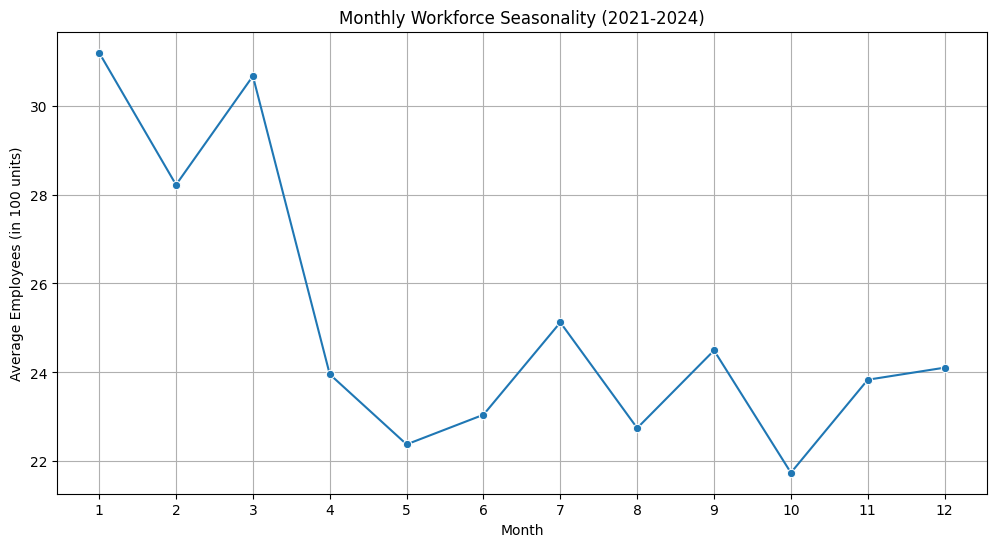

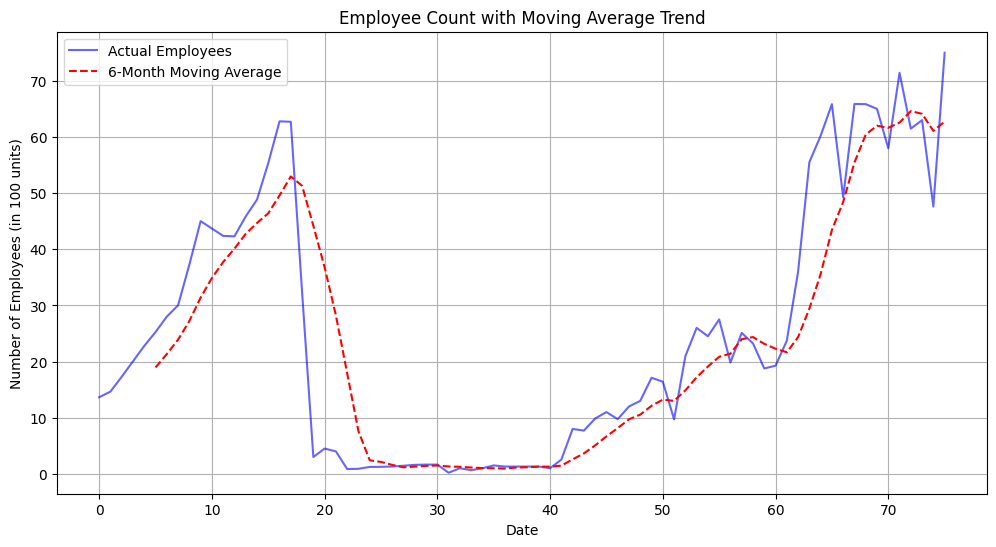

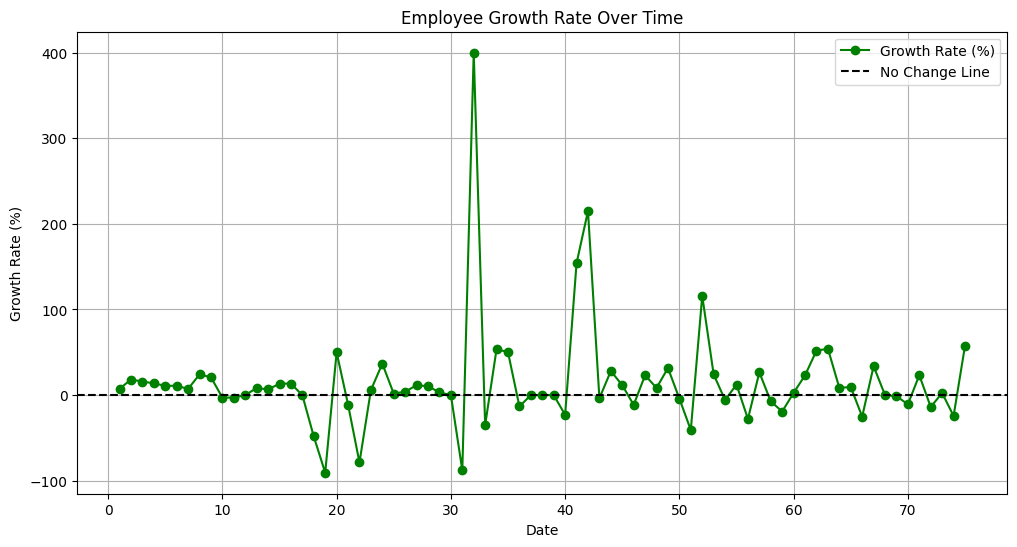

In [ ]:
# Seasonality Analysis
monthly_seasonality = df_site.groupby("Month")["No of Employees (in 100 units)"].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_seasonality.index, y=monthly_seasonality.values, marker='o')
plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Average Employees (in 100 units)")
plt.title("Monthly Workforce Seasonality (2021-2024)")
plt.grid(True)
plt.show()

# Moving Average to Observe Smoother Trends
df_site['Moving_Avg'] = df_site['No of Employees (in 100 units)'].rolling(window=6).mean()

plt.figure(figsize=(12, 6))
plt.plot(df_site.index, df_site['No of Employees (in 100 units)'], label="Actual Employees", color='blue', alpha=0.6)
plt.plot(df_site.index, df_site['Moving_Avg'], label="6-Month Moving Average", color='red', linestyle="--")
plt.xlabel("Date")
plt.ylabel("Number of Employees (in 100 units)")
plt.title("Employee Count with Moving Average Trend")
plt.legend()
plt.grid(True)
plt.show()

# Identify Growth Rate Trends
df_site['Employee_Growth'] = df_site['No of Employees (in 100 units)'].pct_change() * 100

plt.figure(figsize=(12, 6))
plt.plot(df_site.index, df_site['Employee_Growth'], marker='o', linestyle='-', color='green', label='Growth Rate (%)')
plt.axhline(y=0, color='black', linestyle='--', label="No Change Line")
plt.xlabel('Date')
plt.ylabel('Growth Rate (%)')
plt.title('Employee Growth Rate Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Aggregate employee count by Quarter and Half Year for trend analysis
quarterly_trend = df_site.groupby(['FY', 'Quarter'])['No of Employees (in 100 units)'].mean().reset_index()
half_yearly_trend = df_site.groupby(['FY', 'Half Year'])['No of Employees (in 100 units)'].mean().reset_index()
display(quarterly_trend)
display(half_yearly_trend)

,FY,Quarter,No of Employees (in 100 units)
0,FY2019,Q3,15.196667
1,FY2019,Q4,22.693333
2,FY2020,Q1,31.760000
3,FY2020,Q2,43.690000
4,FY2020,Q3,45.660000
5,FY2020,Q4,60.273333
6,FY2021,Q1,13.286667
7,FY2021,Q2,1.916667
8,FY2021,Q3,1.260000
9,FY2021,Q4,1.566667


,FY,Half Year,No of Employees (in 100 units)
0,FY2019,H2,18.945000
1,FY2020,H1,37.725000
2,FY2020,H2,52.966667
3,FY2021,H1,7.601667
4,FY2021,H2,1.413333
5,FY2022,H1,1.000000
6,FY2022,H2,1.456667
7,FY2023,H1,9.716667
8,FY2023,H2,17.195000
9,FY2024,H1,23.155000


In [ ]:
# Convert Quarter and Half Year columns to categorical types
df_site['Quarter'] = df_site['Quarter'].astype(str)
df_site['Half Year'] = df_site['Half Year'].astype(str)

# Quarterly Growth Analysis
quarterly_growth_df = df_site.groupby(['FY', 'Quarter'])['No of Employees (in 100 units)'].mean().pct_change() * 100
quarterly_growth_df = quarterly_growth_df.reset_index().rename(columns={'No of Employees (in 100 units)': 'Quarterly Growth (%)'})

# Half-Yearly Growth Analysis
half_yearly_growth_df = df_site.groupby(['FY', 'Half Year'])['No of Employees (in 100 units)'].mean().pct_change() * 100
half_yearly_growth_df = half_yearly_growth_df.reset_index().rename(columns={'No of Employees (in 100 units)': 'Half-Yearly Growth (%)'})

display(quarterly_growth_df)
display(half_yearly_growth_df)

,FY,Quarter,Quarterly Growth (%)
0,FY2019,Q3,NaN
1,FY2019,Q4,49.330994
2,FY2020,Q1,39.952996
3,FY2020,Q2,37.562972
4,FY2020,Q3,4.509041
5,FY2020,Q4,32.004672
6,FY2021,Q1,-77.955978
7,FY2021,Q2,-85.574511
8,FY2021,Q3,-34.260870
9,FY2021,Q4,24.338624


,FY,Half Year,Half-Yearly Growth (%)
0,FY2019,H2,NaN
1,FY2020,H1,99.129058
2,FY2020,H2,40.402032
3,FY2021,H1,-85.648206
4,FY2021,H2,-81.407586
5,FY2022,H1,-29.245283
6,FY2022,H2,45.666667
7,FY2023,H1,567.048055
8,FY2023,H2,76.963979
9,FY2024,H1,34.661239


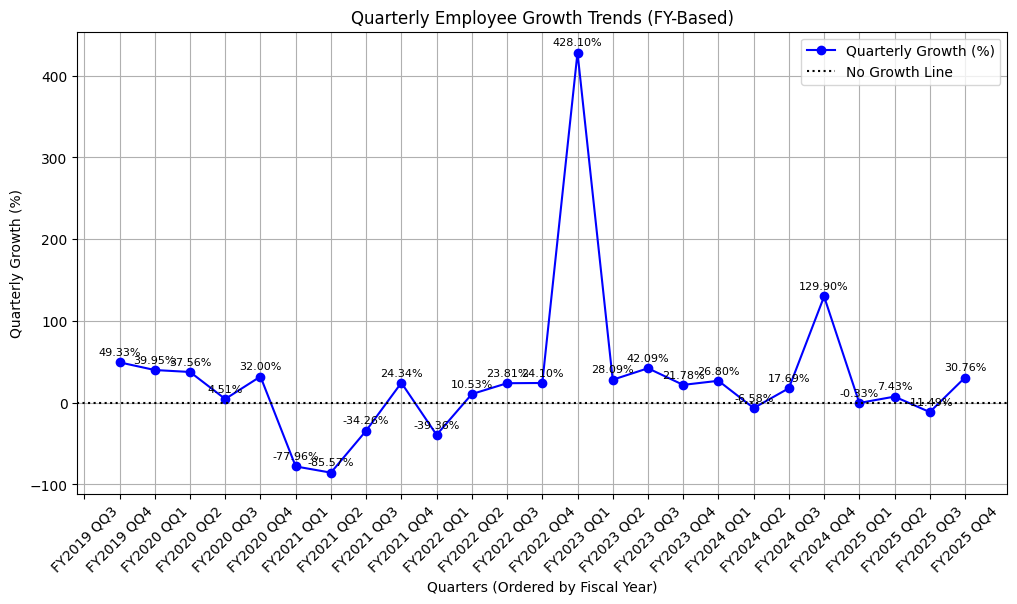

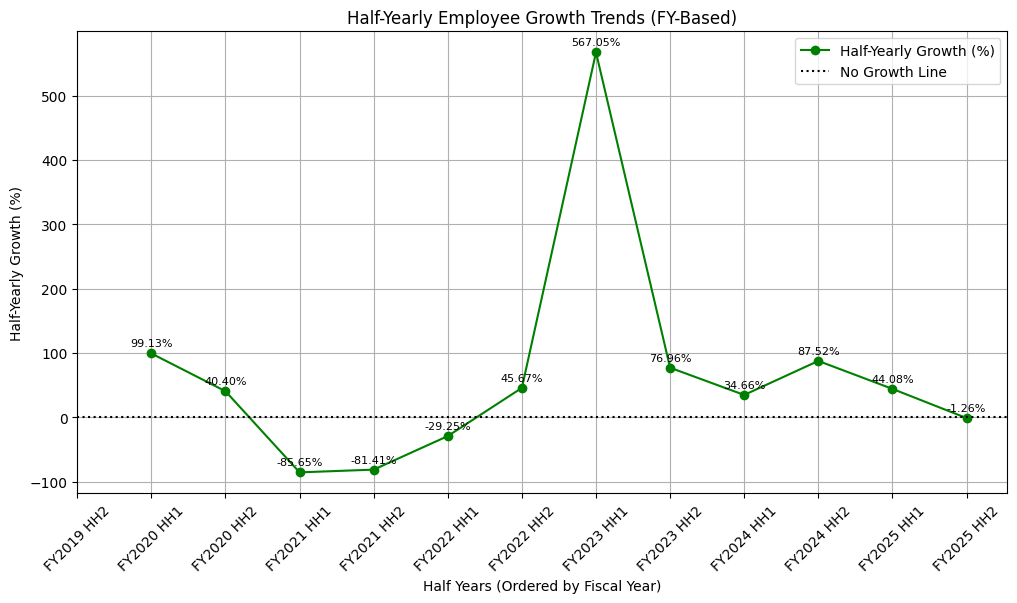

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(quarterly_growth_df.index, quarterly_growth_df['Quarterly Growth (%)'], marker='o', linestyle='-', color='blue', label="Quarterly Growth (%)")

# Annotate each point with its exact value
for i, txt in enumerate(quarterly_growth_df['Quarterly Growth (%)']):
    if not pd.isna(txt):
        plt.annotate(f"{txt:.2f}%", (quarterly_growth_df.index[i], txt),
                     textcoords="offset points", xytext=(0,5), ha='center', fontsize=8)

# Set plot labels and title
plt.axhline(y=0, color='black', linestyle='dotted', label="No Growth Line")
plt.xlabel("Quarters (Ordered by Fiscal Year)")
plt.ylabel("Quarterly Growth (%)")
plt.title("Quarterly Employee Growth Trends (FY-Based)")
plt.legend()
plt.grid(True)
plt.xticks(ticks=quarterly_growth_df.index, labels=[f"{fy} Q{q}" for fy, q in zip(quarterly_growth_df['FY'], quarterly_growth_df['Quarter'])], rotation=45)
plt.show()

# Plot Half-Yearly Growth Trends
plt.figure(figsize=(12, 6))
plt.plot(half_yearly_growth_df.index, half_yearly_growth_df['Half-Yearly Growth (%)'], marker='o', linestyle='-', color='green', label="Half-Yearly Growth (%)")

# Annotate each point with its exact value
for i, txt in enumerate(half_yearly_growth_df['Half-Yearly Growth (%)']):
    if not pd.isna(txt):
        plt.annotate(f"{txt:.2f}%", (half_yearly_growth_df.index[i], txt),
                     textcoords="offset points", xytext=(0,5), ha='center', fontsize=8)

# Set plot labels and title
plt.axhline(y=0, color='black', linestyle='dotted', label="No Growth Line")
plt.xlabel("Half Years (Ordered by Fiscal Year)")
plt.ylabel("Half-Yearly Growth (%)")
plt.title("Half-Yearly Employee Growth Trends (FY-Based)")
plt.legend()
plt.grid(True)
plt.xticks(ticks=half_yearly_growth_df.index, labels=[f"{fy} H{h}" for fy, h in zip(half_yearly_growth_df['FY'], half_yearly_growth_df['Half Year'])], rotation=45)
plt.show()


In [ ]:
valid_growth_df = quarterly_growth_df.dropna()

# Group by fiscal quarter and calculate average
avg_growth_by_quarter = valid_growth_df.groupby('Quarter')['Quarterly Growth (%)'].mean().reset_index()
avg_growth_by_quarter.rename(columns={'Quarterly Growth (%)': 'Avg FY Quarterly Growth (%)'}, inplace=True)

# Sort by Quarter order (Q1 → Q4)
avg_growth_by_quarter['Quarter_Num'] = avg_growth_by_quarter['Quarter'].str.extract(r'Q([1-4])').astype(int)
avg_growth_by_quarter = avg_growth_by_quarter.sort_values('Quarter_Num').drop(columns='Quarter_Num')
print(avg_growth_by_quarter)

  Quarter  Avg FY Quarterly Growth (%)
0      Q1                    62.866686
1      Q2                    -1.424409
2      Q3                     7.058379
3      Q4                    44.601514


##FY Quarter	Avg Growth (%)	Interpretation  (assumptions) for KODATHI
- Q1	+62.87%	 Major hiring spree – campus onboarding, project kickoffs
- Q2	-1.42%	 Stabilization or slight attrition – project reshuffles
- Q3	+7.06%	 Gradual rebound or internal transfers
- Q4	+44.60%	 Strong end-of-year ramp-up – lateral hiring, closing targets


We want realistic, repeatable assumptions — not extreme spikes.

Here’s a refined assumption table, damping the outliers:

FY Quarter	Forecast Assumption	Notes
- Q1	+10%	Conservative estimate (vs +62% historical) to reflect sustainable hiring
- Q2	-2%	Small dip or attrition, aligned with past
- Q3	+3%	Mild growth – backfilling or lateral moves
- Q4	+6%	Healthy growth – aligned with past Q4 hiring


## Additions for Long-Term Forecast
Add a cap: max employees = seat capacity

Add noise: simulate uncertainty (e.g., ±2% each quarter)

MAY Add recession year: e.g., assume -10% in FY2030



- Accuracy on short-term ≠ Accuracy on long-term

Let’s understand this with an analogy:

Scenario	What ARIMA Does	What Happens

- Next 12 months- 	Great fit to past trend and seasonality	- Low error (best model!)
- Next 20 years (2043)	- Assumes past patterns repeat	- Over-simplifies real future


- Future becomes too uncertain	Define high/low/realistic cases based on business plans
- ARIMA fails to see strategy shifts (e.g., AI replacing jobs, WFH)	Use “What-if” assumptions and seat plans


FY Quarter	Assumption	Months	Logic from Historical Data
- Q1	+10% growth	Apr–May–Jun	Strong hiring after fiscal reset
- Q2	-2% decline	Jul–Aug–Sep	Mild attrition / stabilizing
- Q3	+3% growth	Oct–Nov–Dec	Controlled mid-year hiring
- Q4	+6% growth	Jan–Feb–Mar	Year-end hiring burst
-- These were intentionally conservative for baseline planning — to avoid overly optimistic projections in long-term forecasts.



# Assumptions for Net Employee Growth/Decline by Quarter (Fiscal Year: April - March)

**Q1: April–May–June - Post Fiscal Year Reset & Growth Initiation: +5% to +12% Net Growth**

**Reasoning:** Strong hiring driven by new budgets, strategic project starts, and campus recruitment significantly outweighs attrition, leading to substantial growth. The range accounts for variations in company growth ambitions and industry demand.

**Q2: July–August–September - Mid-Year Review & Stabilization: -3% to +1% Net Change**

**Reasoning:** Hiring slows down from the Q1 peak, while natural attrition and potential mid-year performance-related departures can lead to a slight decline or very minimal growth. The range reflects different levels of attrition and targeted hiring.

**Q3: October–November–December - Strategic Adjustments & Year-End Preparation: +1% to +5% Net Growth**

**Reasoning:** Hiring becomes more strategic to fill key gaps and prepare for the next fiscal year. Attrition is usually stable. This results in moderate, controlled growth.

**Q4: January–February–March - Year-End Review & Preparation for Next FY: +2% to +7% Net Growth**

**Reasoning:** Final push to meet annual goals and hiring for critical roles in the upcoming fiscal year contribute to growth. However, potential pre-bonus attrition might slightly offset this.

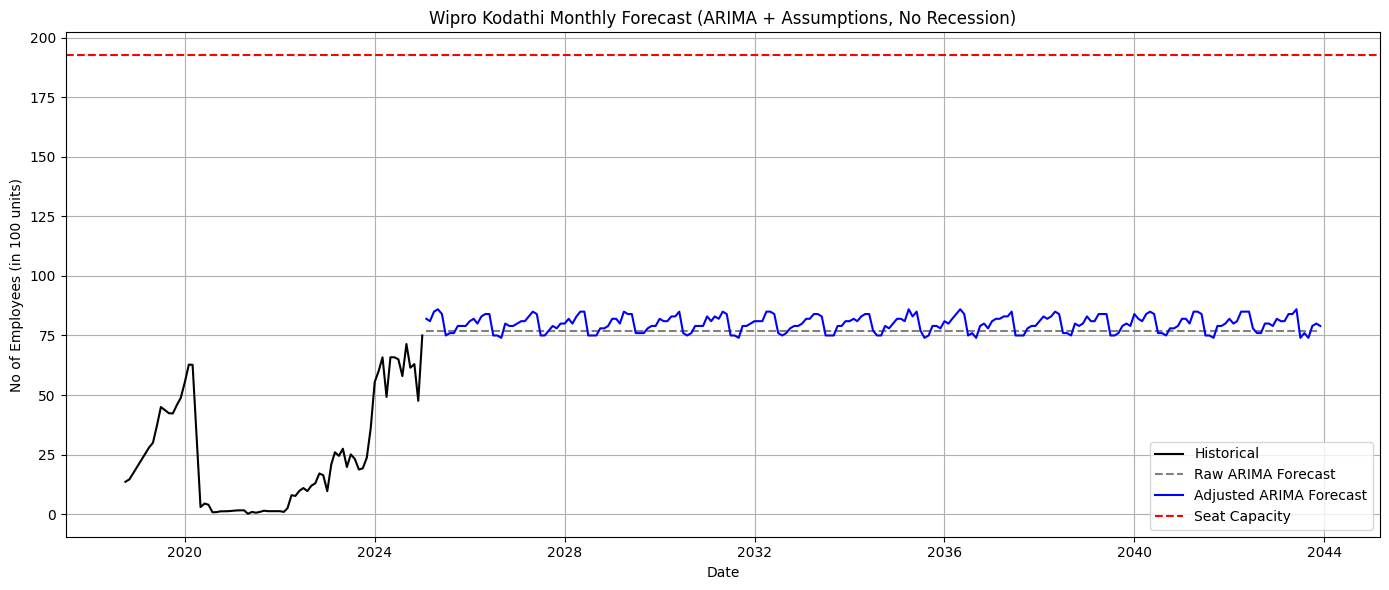

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import os

np.random.seed(42)

# Step 1: Define Business Assumptions
quarterly_growth = {
    "Q1": 1.10,  # Apr–Jun
    "Q2": 0.98,  # Jul–Sep
    "Q3": 1.03,  # Oct–Dec
    "Q4": 1.06   # Jan–Mar
}

seat_capacity = df_site['No of Seats (in 100 units)'].max()
sft_served = df_site['Sft Served (in 1,00,000 units)'].mean()
site_name = "Kodathi"
city_name = "Bangalore"
noise_std = 0.01

# Step 2: Fit ARIMA Model
model_arima = ARIMA(df_emp['No of Employees (in 100 units)'], order=(0, 1, 1))
model_arima_fit = model_arima.fit()

# Step 3: Create Forecast Index
last_date = df_emp.index[-1]
forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=1), end='2043-12-01', freq='MS')

# Step 4: Forecast Monthly till Dec 2043
arima_forecast = model_arima_fit.forecast(steps=len(forecast_index))
arima_forecast.index = forecast_index

# Step 5: Apply Assumptions to Forecast (no recession, no seat count in output)
adjusted_forecast = []
for date in forecast_index:
    month = date.month

    # Identify quarter
    if month in [4, 5, 6]:
        q_label = "Q1"
    elif month in [7, 8, 9]:
        q_label = "Q2"
    elif month in [10, 11, 12]:
        q_label = "Q3"
    else:
        q_label = "Q4"

    # Apply multiplier with noise
    multiplier = quarterly_growth[q_label]
    multiplier *= np.random.normal(loc=1.0, scale=noise_std)

    # Final adjusted value (cap at seat capacity)
    val = min(arima_forecast[date] * multiplier, seat_capacity)

    adjusted_forecast.append({
        "Date": date.strftime('%Y-%m-%d'),
        "Site": site_name,
        "No of Employees (in 100 units)": round(val),
        "Sft Served (in 1,00,000 units)": round(sft_served, 2)
    })

# Step 6: Create Forecast DataFrame
forecast_df_arima_f = pd.DataFrame(adjusted_forecast)

# Step 7: Plot Historical vs Forecast
plt.figure(figsize=(14, 6))
plt.plot(df_emp.index, df_emp['No of Employees (in 100 units)'], label='Historical', color='black')
plt.plot(arima_forecast.index, arima_forecast, label='Raw ARIMA Forecast', linestyle='--', color='gray')
plt.plot(pd.to_datetime(forecast_df_arima_f['Date']), forecast_df_arima_f['No of Employees (in 100 units)'], label='Adjusted ARIMA Forecast', color='blue')
plt.axhline(seat_capacity, color='red', linestyle='--', label='Seat Capacity')
plt.title('Wipro Kodathi Monthly Forecast (ARIMA + Assumptions, No Recession)')
plt.xlabel('Date')
plt.ylabel('No of Employees (in 100 units)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 8: Save to CSV
os.makedirs("forecast_output", exist_ok=True)
forecast_df_arima_f.to_csv("forecast_output/Wipro_Kodathi_ARIMA_Forecast_2025_2043.csv", index=False)

In [ ]:
df_site.columns

Index(['Date', 'City', 'Site (Facility)', 'No of Employees',
       'Total Units of Purchased Electricity Kwh', 'DG Units in kWh',
       'Percentage Occupancy', 'No of Seats', 'Sft Served', 'FY', 'Quarter',
       'Half Year', 'Total Generated Electricity by Wipro', 'Year', 'Month',
       'Sft Served (in 1,00,000 units)', 'DG Units in kWh (in 1000 units)',
       'No of Employees (in 100 units)', 'No of Seats (in 100 units)',
       'Total Generated Electricity (in 1000 units)', 'Moving_Avg',
       'Employee_Growth'],
      dtype='object')

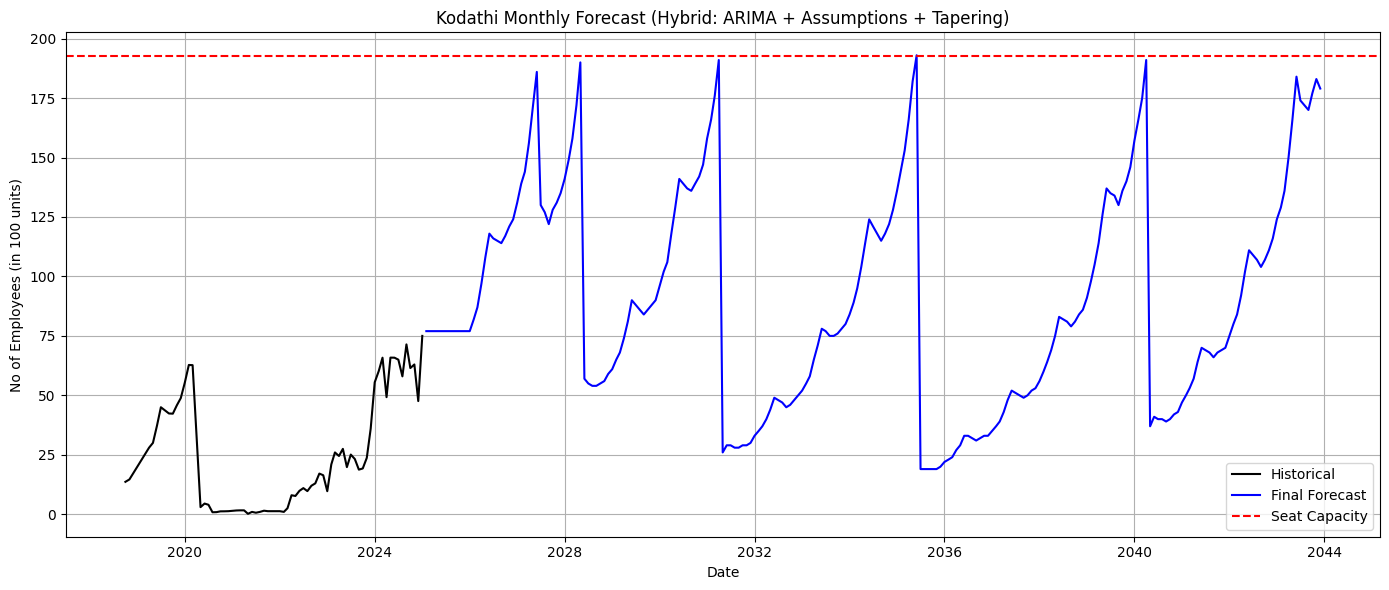

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import os

np.random.seed(42)

# Business Assumptions
quarterly_growth = {
    "Q1": 1.10,
    "Q2": 0.98,
    "Q3": 1.03,
    "Q4": 1.06
}
noise_std = 0.01
taper_threshold = 0.95

# Site Info
seat_capacity = df_site['No of Seats (in 100 units)'].max()
sft_served = df_site['Sft Served (in 1,00,000 units)'].mean()
site_name = df_site['Site (Facility)'].iloc[0]
city_name = 'Bangalore'

# Fit ARIMA
arima_model = ARIMA(df_emp['No of Employees (in 100 units)'], order=(1, 1, 1))
arima_result = arima_model.fit()

# ARIMA Forecast: First 12 months
arima_forecast_horizon = 12
arima_forecast = arima_result.forecast(steps=arima_forecast_horizon).clip(upper=seat_capacity)

# Full forecast timeline
last_date = df_emp.index[-1]
forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=1), end='2043-12-01', freq='MS')

adjusted_forecast = []

# Step 1: Add ARIMA Forecast for First 12 Months
for i, date in enumerate(forecast_index[:arima_forecast_horizon]):
    val = arima_forecast.iloc[i]
    adjusted_forecast.append({
        "Date": date.strftime('%Y-%m-%d'),
        "City": city_name,
        "Site": site_name,
        "No of Employees (in 100 units)": round(val),
        "Sft Served (in 1,00,000 units)": round(sft_served, 2)
    })
current_val = arima_forecast.iloc[-1]  # use last ARIMA value

# Step 2: Recursive Growth After ARIMA
for date in forecast_index[arima_forecast_horizon:]:
    month = date.month
    # Determine fiscal quarter
    if month in [4, 5, 6]:
        q_label = "Q1"
    elif month in [7, 8, 9]:
        q_label = "Q2"
    elif month in [10, 11, 12]:
        q_label = "Q3"
    else:
        q_label = "Q4"

    # Growth multiplier with noise
    multiplier = quarterly_growth[q_label] * np.random.normal(loc=1.0, scale=noise_std)

    # Tapering near capacity
    if current_val >= taper_threshold * seat_capacity:
        slowdown = 1 - ((current_val - taper_threshold * seat_capacity) / (seat_capacity * (1 - taper_threshold)))
        multiplier *= max(slowdown, 0.1)

    current_val = min(current_val * multiplier, seat_capacity)

    adjusted_forecast.append({
        "Date": date.strftime('%Y-%m-%d'),
        "City": city_name,
        "Site": site_name,
        "No of Employees (in 100 units)": round(current_val),
        "Sft Served (in 1,00,000 units)": round(sft_served, 2)
    })

# Final forecast dataframe
forecast_df = pd.DataFrame(adjusted_forecast)

# Plotting
plt.figure(figsize=(14, 6))
plt.plot(df_emp.index, df_emp['No of Employees (in 100 units)'], label='Historical', color='black')
plt.plot(pd.to_datetime(forecast_df['Date']), forecast_df['No of Employees (in 100 units)'], label='Final Forecast', color='blue')
plt.axhline(seat_capacity, linestyle='--', color='red', label='Seat Capacity')
plt.title(f'{site_name} Monthly Forecast (Hybrid: ARIMA + Assumptions + Tapering)')
plt.xlabel("Date")
plt.ylabel("No of Employees (in 100 units)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Save forecast
os.makedirs("forecast_output", exist_ok=True)
filename = f"forecast_output/Wipro_{site_name.replace(' ', '_')}_Stable_Forecast_2025_2043.csv"
forecast_df.to_csv(filename, index=False)


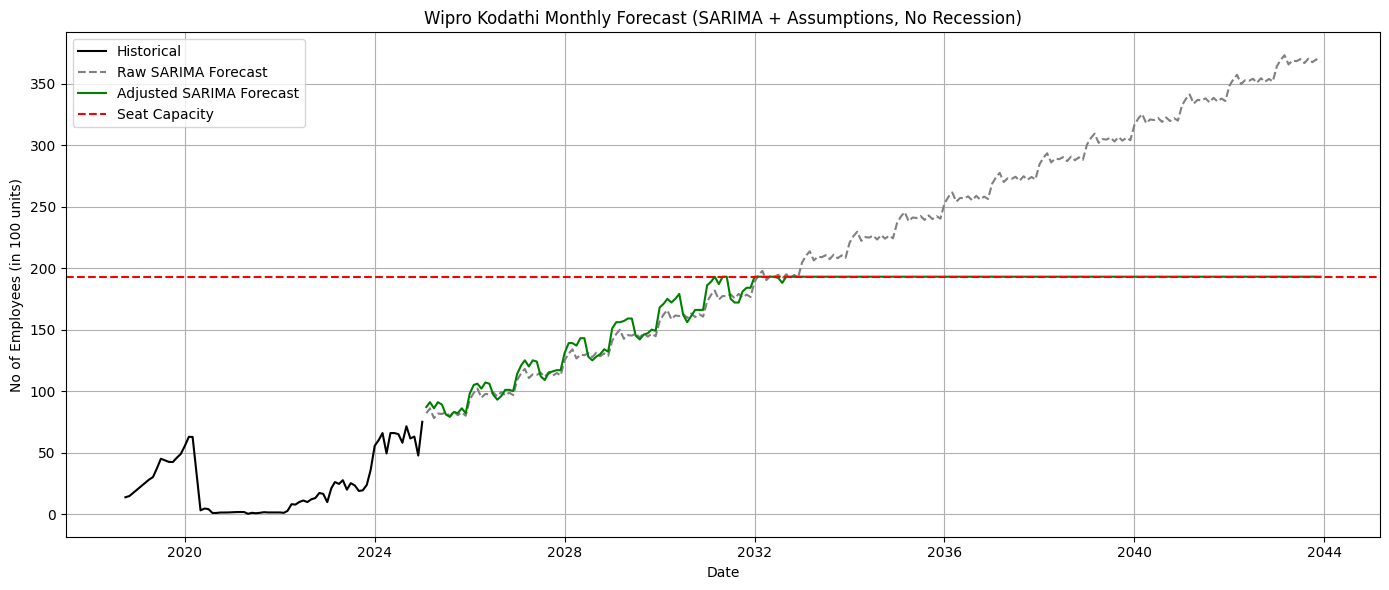

,Date,Site,No of Employees (in 100 units),"Sft Served (in 1,00,000 units)"
0,2025-02-01,Kodathi,87,24.86
1,2025-03-01,Kodathi,91,24.86
2,2025-04-01,Kodathi,86,24.86
3,2025-05-01,Kodathi,91,24.86
4,2025-06-01,Kodathi,89,24.86
...,...,...,...,...
222,2043-08-01,Kodathi,193,24.86
223,2043-09-01,Kodathi,193,24.86
224,2043-10-01,Kodathi,193,24.86
225,2043-11-01,Kodathi,193,24.86


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

np.random.seed(42)

# Step 1: Define Business Assumptions
quarterly_growth = {
    "Q1": 1.10,
    "Q2": 0.98,
    "Q3": 1.03,
    "Q4": 1.06
}

seat_capacity = df_site['No of Seats (in 100 units)'].max()
sft_served = df_site['Sft Served (in 1,00,000 units)'].mean()
site_name = df_site['Site (Facility)'].iloc[0]
noise_std = 0.01

# Step 2: Refit SARIMA Model
model_sarima = SARIMAX(df_emp['No of Employees (in 100 units)'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_sarima_fit = model_sarima.fit()

# Step 3: Forecast Timeline
last_date = df_emp.index[-1]
forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=1), end='2043-12-01', freq='MS')

# Step 4: Forecast Monthly till Dec 2043
sarima_forecast = model_sarima_fit.forecast(steps=len(forecast_index))
sarima_forecast.index = forecast_index

# Step 5: Apply Quarterly Assumptions (no recession)
adjusted_sarima_forecast = []
for date in forecast_index:
    month = date.month

    # Identify quarter
    if month in [4, 5, 6]:
        q_label = "Q1"
    elif month in [7, 8, 9]:
        q_label = "Q2"
    elif month in [10, 11, 12]:
        q_label = "Q3"
    else:
        q_label = "Q4"

    # Apply quarterly multiplier with noise
    multiplier = quarterly_growth[q_label]
    multiplier *= np.random.normal(loc=1.0, scale=noise_std)

    # Apply cap to seat capacity
    val = min(sarima_forecast[date] * multiplier, seat_capacity)

    adjusted_sarima_forecast.append({
        "Date": date.strftime('%Y-%m-%d'),
        "Site": site_name,
        "No of Employees (in 100 units)": round(val),
        "Sft Served (in 1,00,000 units)": round(sft_served, 2)
    })

# Step 6: Create Forecast DataFrame
forecast_df_sarima = pd.DataFrame(adjusted_sarima_forecast)

# Step 7: Plot Historical vs Forecast
plt.figure(figsize=(14, 6))
plt.plot(df_emp.index, df_emp['No of Employees (in 100 units)'], label='Historical', color='black')
plt.plot(sarima_forecast.index, sarima_forecast, label='Raw SARIMA Forecast', linestyle='--', color='gray')
plt.plot(pd.to_datetime(forecast_df_sarima['Date']), forecast_df_sarima['No of Employees (in 100 units)'], label='Adjusted SARIMA Forecast', color='green')
plt.axhline(seat_capacity, color='red', linestyle='--', label='Seat Capacity')
plt.title('Wipro Kodathi Monthly Forecast (SARIMA + Assumptions, No Recession)')
plt.xlabel('Date')
plt.ylabel('No of Employees (in 100 units)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 8: Save to CSV
os.makedirs("forecast_output", exist_ok=True)
forecast_df_sarima.to_csv("forecast_output/Wipro_Kodathi_SARIMA_Forecast_2025_2043.csv", index=False)

# Step 9: Display DataFrame
display(forecast_df_sarima)

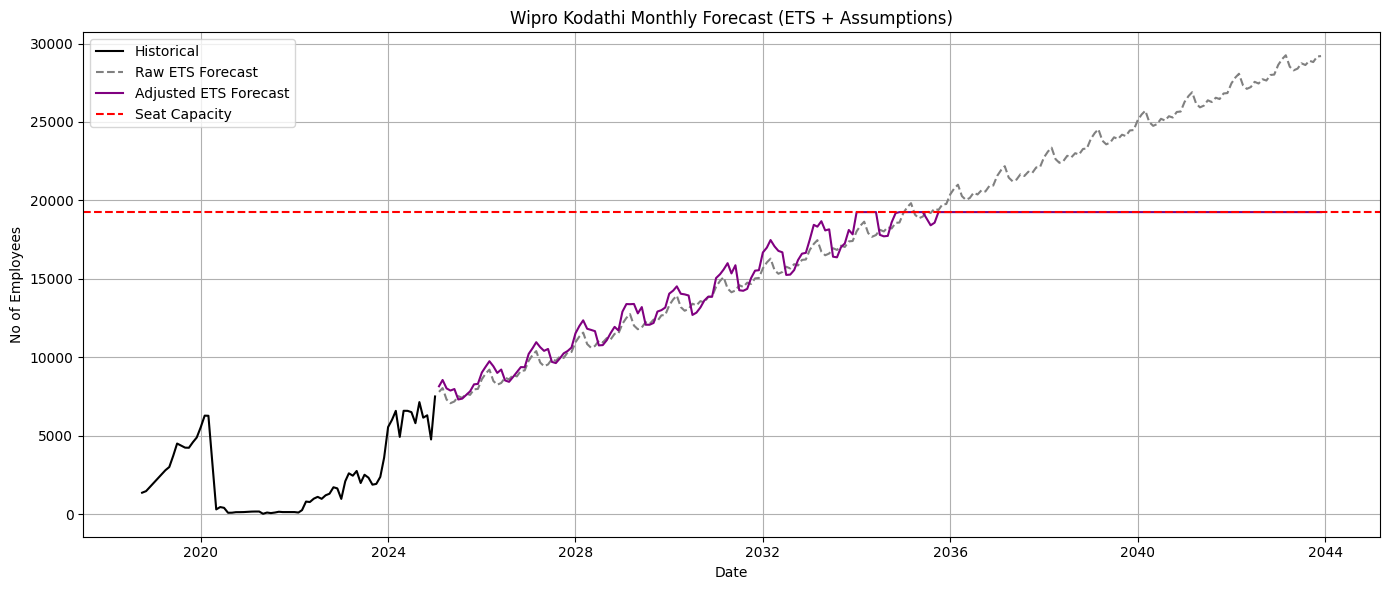

,Date,City,Site,No of Employees,No of Seats,Sft Served
0,2025-02-01,Bangalore,Kodathi,8151,19255,2621000.75
1,2025-03-01,Bangalore,Kodathi,8552,19255,2621000.75
2,2025-04-01,Bangalore,Kodathi,8014,19255,2621000.75
3,2025-05-01,Bangalore,Kodathi,7878,19255,2621000.75
4,2025-06-01,Bangalore,Kodathi,7975,19255,2621000.75
...,...,...,...,...,...,...
222,2043-08-01,Bangalore,Kodathi,19255,19255,2621000.75
223,2043-09-01,Bangalore,Kodathi,19255,19255,2621000.75
224,2043-10-01,Bangalore,Kodathi,19255,19255,2621000.75
225,2043-11-01,Bangalore,Kodathi,19255,19255,2621000.75


In [ ]:
# from statsmodels.tsa.holtwinters import ExponentialSmoothing

# # Step 1: Fit ETS Model
# ets_model = ExponentialSmoothing(df_emp['No of Employees'], trend='add', seasonal='add', seasonal_periods=12)
# ets_model_fit = ets_model.fit()

# # Step 2: Forecast Monthly till Dec 2043
# ets_forecast = ets_model_fit.forecast(steps=len(forecast_index))
# ets_forecast.index = forecast_index

# # Step 3: Apply Assumptions to Forecast
# adjusted_ets_forecast = []
# for date in forecast_index:
#     month = date.month
#     year = date.year
#     fy_year = year if month >= 4 else year - 1

#     if month in [4, 5, 6]:
#         q_label = "Q1"
#     elif month in [7, 8, 9]:
#         q_label = "Q2"
#     elif month in [10, 11, 12]:
#         q_label = "Q3"
#     else:
#         q_label = "Q4"

#     multiplier = quarterly_growth[q_label]
#     if fy_year == recession_year:
#         multiplier *= 0.975
#     multiplier *= np.random.normal(loc=1.0, scale=noise_std)

#     val = min(ets_forecast[date] * multiplier, seat_capacity)

#     adjusted_ets_forecast.append({
#         "Date": date.strftime('%Y-%m-%d'),
#         "City": city_name,
#         "Site": site_name,
#         "No of Employees": round(val),
#         "No of Seats": seat_capacity,
#         "Sft Served": round(sft_served, 2)
#     })

# # Step 4: Create Forecast DataFrame
# forecast_df_ets = pd.DataFrame(adjusted_ets_forecast)

# # Step 5: Plot Historical vs Forecast
# plt.figure(figsize=(14, 6))
# plt.plot(df_emp.index, df_emp['No of Employees'], label='Historical', color='black')
# plt.plot(ets_forecast.index, ets_forecast, label='Raw ETS Forecast', linestyle='--', color='gray')
# plt.plot(pd.to_datetime(forecast_df_ets['Date']), forecast_df_ets['No of Employees'], label='Adjusted ETS Forecast', color='purple')
# plt.axhline(seat_capacity, color='red', linestyle='--', label='Seat Capacity')
# plt.title('Wipro Kodathi Monthly Forecast (ETS + Assumptions)')
# plt.xlabel('Date')
# plt.ylabel('No of Employees')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # Step 6: Save CSV
# os.makedirs("forecast_output", exist_ok=True)
# forecast_df_ets.to_csv("forecast_output/Wipro_Kodathi_ETS_Forecast_2025_2043.csv", index=False)
# display(forecast_df_ets)

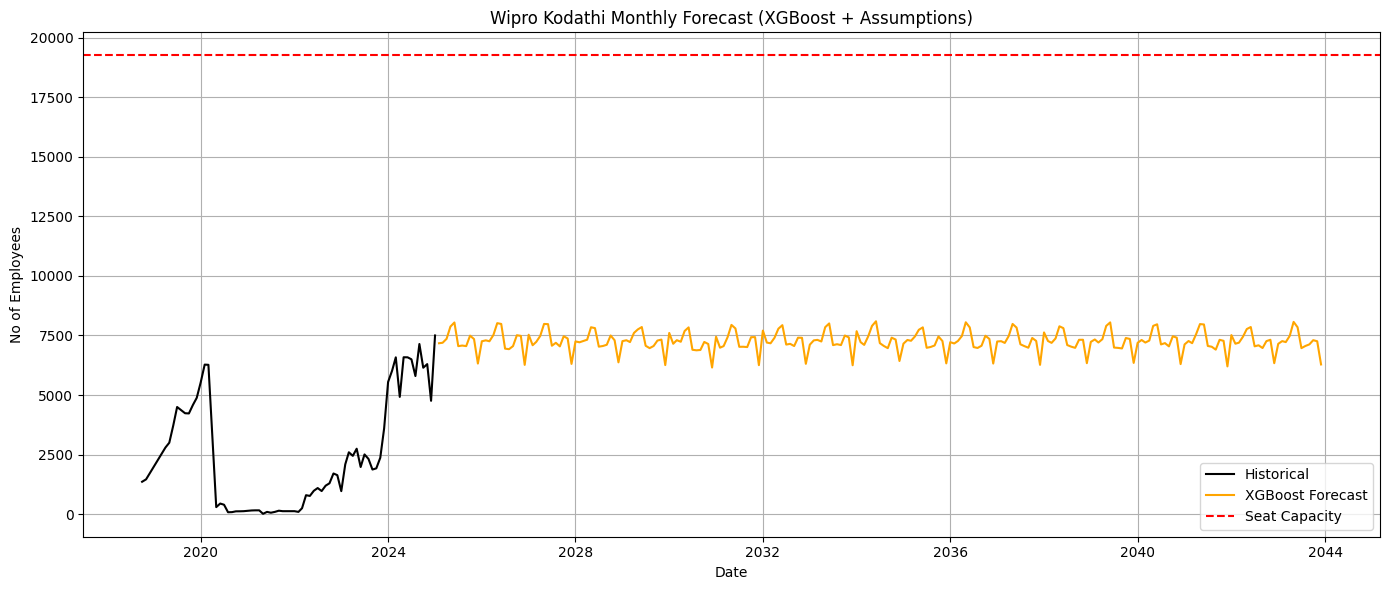

,Date,City,Site,No of Employees,No of Seats,Sft Served
0,2025-02-01,Bangalore,Kodathi,7175.0,19255,2621000.75
1,2025-03-01,Bangalore,Kodathi,7195.0,19255,2621000.75
2,2025-04-01,Bangalore,Kodathi,7361.0,19255,2621000.75
3,2025-05-01,Bangalore,Kodathi,7875.0,19255,2621000.75
4,2025-06-01,Bangalore,Kodathi,8045.0,19255,2621000.75
...,...,...,...,...,...,...
222,2043-08-01,Bangalore,Kodathi,7060.0,19255,2621000.75
223,2043-09-01,Bangalore,Kodathi,7127.0,19255,2621000.75
224,2043-10-01,Bangalore,Kodathi,7303.0,19255,2621000.75
225,2043-11-01,Bangalore,Kodathi,7257.0,19255,2621000.75


In [ ]:
# from xgboost import XGBRegressor
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# # Step 1: Create features from date
# df_features = df_emp.copy()
# df_features['Month'] = df_features.index.month
# df_features['Year'] = df_features.index.year
# df_features['Quarter'] = df_features.index.quarter

# # Step 2: Lag feature (previous month's employees)
# df_features['Lag_1'] = df_features['No of Employees'].shift(1)
# df_features = df_features.dropna()

# # Step 3: Train-Test Split (train on all historical data)
# X = df_features[['Month', 'Year', 'Quarter', 'Lag_1']]
# y = df_features['No of Employees']
# model_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
# model_xgb.fit(X, y)

# # Step 4: Forecast from Feb 2025 to Dec 2043
# future_dates = pd.date_range(start='2025-02-01', end='2043-12-01', freq='MS')
# future_df = pd.DataFrame(index=future_dates)
# future_df['Month'] = future_df.index.month
# future_df['Year'] = future_df.index.year
# future_df['Quarter'] = future_df.index.quarter

# # Step 5: Recursive Forecasting using lag
# last_known = df_emp.iloc[-1]['No of Employees']
# lag_vals = [last_known]

# for i in range(len(future_df)):
#     row = future_df.iloc[i][['Month', 'Year', 'Quarter']].values.tolist() + [lag_vals[-1]]
#     prediction = model_xgb.predict([row])[0]

#     # Apply business assumptions (same as ARIMA/ETS/SARIMA)
#     date = future_df.index[i]
#     month = date.month
#     year = date.year
#     fy_year = year if month >= 4 else year - 1

#     if month in [4, 5, 6]:
#         q_label = "Q1"
#     elif month in [7, 8, 9]:
#         q_label = "Q2"
#     elif month in [10, 11, 12]:
#         q_label = "Q3"
#     else:
#         q_label = "Q4"

#     multiplier = quarterly_growth[q_label]
#     if fy_year == recession_year:
#         multiplier *= 0.975
#     multiplier *= np.random.normal(loc=1.0, scale=noise_std)
#     adjusted_pred = min(prediction * multiplier, seat_capacity)

#     lag_vals.append(adjusted_pred)

# # Remove initial known value
# forecast_vals = lag_vals[1:]

# # Step 6: Build Forecast DataFrame
# forecast_df_xgb = pd.DataFrame({
#     "Date": future_dates.strftime('%Y-%m-%d'),
#     "City": city_name,
#     "Site": site_name,
#     "No of Employees": np.round(forecast_vals),
#     "No of Seats": seat_capacity,
#     "Sft Served": round(sft_served, 2)
# })

# # Step 7: Plot
# plt.figure(figsize=(14, 6))
# plt.plot(df_emp.index, df_emp['No of Employees'], label='Historical', color='black')
# plt.plot(future_dates, forecast_vals, label='XGBoost Forecast', color='orange')
# plt.axhline(seat_capacity, color='red', linestyle='--', label='Seat Capacity')
# plt.title('Wipro Kodathi Monthly Forecast (XGBoost + Assumptions)')
# plt.xlabel('Date')
# plt.ylabel('No of Employees')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # Step 8: Save and display
# os.makedirs("forecast_output", exist_ok=True)
# forecast_df_xgb.to_csv("forecast_output/Wipro_Kodathi_XGBoost_Forecast_2025_2043.csv", index=False)
# display(forecast_df_xgb)


In [ ]:
# # Define recursive forecasting period (next 60 months for 2025-2030)
# forecast_steps = 60
# forecast_index_future = pd.date_range(start=df_site.index[-1] + pd.DateOffset(months=1), periods=forecast_steps, freq='MS')


# # Perform recursive forecasting
# future_forecast = sarima_result.get_forecast(steps=forecast_steps)
# future_pred_mean = future_forecast.predicted_mean

# # Convert forecast results into a DataFrame
# future_forecast_df = pd.DataFrame({'Date': forecast_index_future, 'Forecasted Employees': future_pred_mean.values})
# future_forecast_df.set_index('Date', inplace=True)

# # Assuming 'test' DataFrame from previous code holds the actual values:
# actual_values = test['No of Employees (in 100 units)']  # Assign actual values to a variable


# # Plot historical data and recursive forecast
# plt.figure(figsize=(14, 6))
# plt.plot(df_site.index, df_site['No of Employees (in 100 units)'], label='Historical Data', linestyle='-')
# plt.plot(test.index, test['No of Employees (in 100 units)'], label='Test Data', marker='o', linestyle='-')
# plt.plot(future_forecast_df.index, future_forecast_df['Forecasted Employees'], label='SARIMA Recursive Forecast (Next 60 months)', marker='o', linestyle='--', color='red')
# plt.xlabel('Date')
# plt.ylabel('Number of Employees (in 100 units)')
# plt.title('SARIMA Model: Recursive 5-Year Employee Forecast (2025–2030)')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()


# display(future_forecast_df)

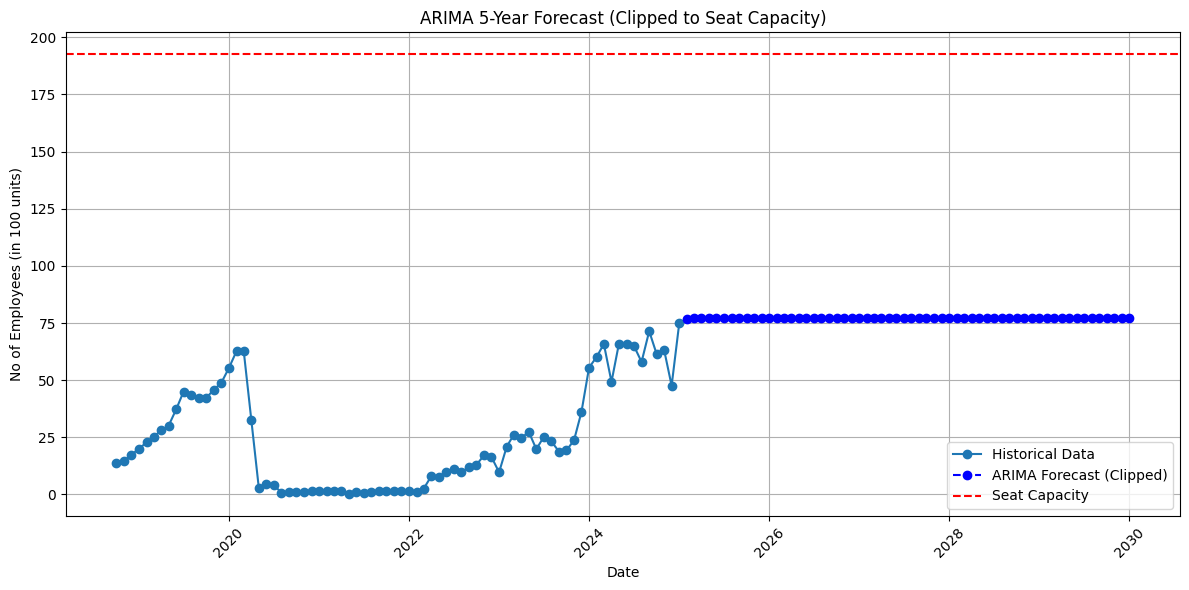

,Date,Clipped Forecasted Employees
2025-02-01,2025-02-01,76.849698
2025-03-01,2025-03-01,77.212028
2025-04-01,2025-04-01,77.283003
2025-05-01,2025-05-01,77.296906
2025-06-01,2025-06-01,77.299630
2025-07-01,2025-07-01,77.300163
2025-08-01,2025-08-01,77.300268
2025-09-01,2025-09-01,77.300288
2025-10-01,2025-10-01,77.300292
2025-11-01,2025-11-01,77.300293


In [ ]:
# === Step 1: Create Employee Time Series ===
df_emp = df_site[['No of Employees (in 100 units)']].copy()

# === Step 2: Fit ARIMA Model ===
model_arima = ARIMA(df_emp['No of Employees (in 100 units)'], order=(1, 1, 1))
model_arima_fit = model_arima.fit()

# === Step 3: Forecast Horizon (60 months) ===
forecast_horizon_arima = 60
forecast_index_arima = pd.date_range(start=df_emp.index[-1] + pd.DateOffset(months=1),
                                     periods=forecast_horizon_arima,
                                     freq='MS')

# === Step 4: Generate Forecast ===
forecast_arima = model_arima_fit.forecast(steps=forecast_horizon_arima)

# === Step 5: Clip Forecast to Seat Capacity ===
seat_capacity = df_site['No of Seats (in 100 units)'].max()
forecast_arima_clipped = np.clip(forecast_arima, a_min=0, a_max=seat_capacity)

# === Step 6: Create Forecast DataFrame ===
forecast_df_arima = pd.DataFrame({
    "Date": forecast_index_arima,
    "Clipped Forecasted Employees": forecast_arima_clipped
})

# === Step 7: Plot Forecast ===
plt.figure(figsize=(12, 6))
plt.plot(df_emp.index, df_emp['No of Employees (in 100 units)'], label="Historical Data", marker='o', linestyle='-')
plt.plot(forecast_index_arima, forecast_arima_clipped, label="ARIMA Forecast (Clipped)", marker='o', linestyle='--', color='blue')
plt.axhline(seat_capacity, color='red', linestyle='--', label='Seat Capacity')
plt.xlabel("Date")
plt.ylabel("No of Employees (in 100 units)")
plt.title("ARIMA 5-Year Forecast (Clipped to Seat Capacity)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# === Step 8: Display Forecast Data ===
display(forecast_df_arima)


In [ ]:
# Define forecast period (last 8 months of actual data for validation)
validation_steps = 8
validation_index = df_site.index[-validation_steps:]

In [ ]:
df_site['Date'] = pd.to_datetime(df_site['Date'], errors='coerce')
df_site = df_site[df_site['Date'].notna()]  # drop any rows with NaT
df_site.set_index('Date', inplace=True)
df_site.index = pd.to_datetime(df_site.index)

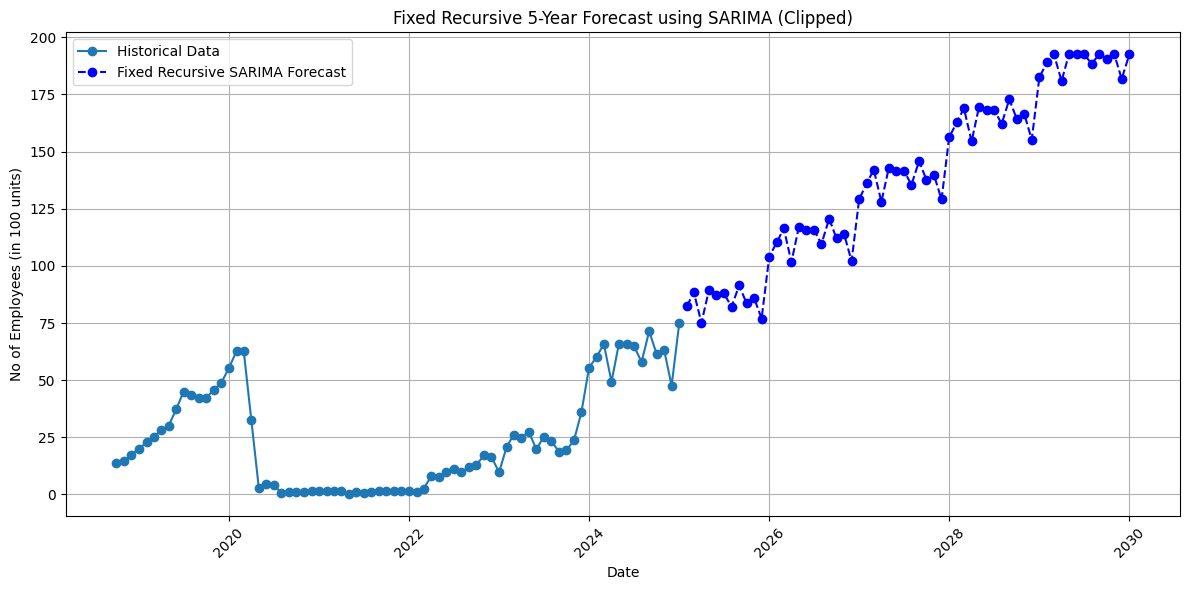

,Date,Recursive Forecasted Employees
2025-02-01,2025-02-01,82.342585
2025-03-01,2025-03-01,88.459826
2025-04-01,2025-04-01,75.070085
2025-05-01,2025-05-01,89.268412
2025-06-01,2025-06-01,87.244195
2025-07-01,2025-07-01,87.975058
2025-08-01,2025-08-01,82.097737
2025-09-01,2025-09-01,91.424693
2025-10-01,2025-10-01,83.674938
2025-11-01,2025-11-01,85.793970


In [ ]:
# Step 1: Fit SARIMA model
sarima_model = SARIMAX(df_site['No of Employees (in 100 units)'],
                       order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
sarima_result = sarima_model.fit()

# Step 2: Define forecast horizon
forecast_horizon_sarima = 60  # 5 years
forecast_index_sarima = pd.date_range(start=df_site.index[-1] + pd.DateOffset(months=1),
                                      periods=forecast_horizon_sarima,
                                      freq='MS')

# Step 3: Generate SARIMA forecast
forecast_sarima = sarima_result.forecast(steps=forecast_horizon_sarima)
# Define max seat capacity (make sure it's already scaled in 100s if you're using scaled values)
seat_capacity = df_site['No of Seats (in 100 units)'].max()
# Step 4: Clip forecast using seat capacity
forecast_sarima = np.clip(forecast_sarima, a_min=0, a_max=seat_capacity)

# Step 5: Create forecast DataFrame
recursive_forecast_sarima_df = pd.DataFrame({
    "Date": forecast_index_sarima,
    "Recursive Forecasted Employees": forecast_sarima
})

# Step 6: Plot SARIMA Forecast
plt.figure(figsize=(12, 6))
plt.plot(df_site.index, df_site['No of Employees (in 100 units)'],
         label="Historical Data", marker='o', linestyle='-')
plt.plot(forecast_index_sarima, forecast_sarima,
         label="Fixed Recursive SARIMA Forecast", marker='o', linestyle='--', color='blue')
plt.xlabel("Date")
plt.ylabel("No of Employees (in 100 units)")
plt.title("Fixed Recursive 5-Year Forecast using SARIMA (Clipped)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 7: Display Forecast Data
display(recursive_forecast_sarima_df)


In [ ]:
# # Fit SARIMA model on training data
# model_sarima = SARIMAX(train_data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
# sarima_result = model_sarima.fit()

# # Generate predictions for the test set
# predictions_sarima = sarima_result.forecast(steps=test_size)
# mae_sarima = mean_absolute_error(test_data, predictions_sarima)
# rmse_sarima = np.sqrt(mean_squared_error(test_data, predictions_sarima))
# mape_sarima = (abs((test_data - predictions_sarima) / test_data).mean()) * 100

# # Display results
# accuracy_metrics_sarima = {
#     "Mean Absolute Error (MAE)": mae_sarima,
#     "Root Mean Squared Error (RMSE)": rmse_sarima,
#     "Mean Absolute Percentage Error (MAPE)": mape_sarima
# }
# accuracy_metrics_sarima

## ETS Model (Exponential Smoothing)

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
ets_model = ExponentialSmoothing(df_site['No of Employees (in 100 units)'], trend='add', seasonal='mul', seasonal_periods=12)
ets_result = ets_model.fit()
ets_result.summary()

Dep. Variable:,No of Employees (in 100 units),No. Observations:,76
Model:,ExponentialSmoothing,SSE,6700.503
Optimized:,True,AIC,372.420
Trend:,Additive,BIC,409.711
Seasonal:,Multiplicative,AICC,384.420
Seasonal Periods:,12,Date:,"Tue, 08 Apr 2025"
Box-Cox:,False,Time:,00:42:53
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.9833455,alpha,True
smoothing_trend,0.1563451,beta,True


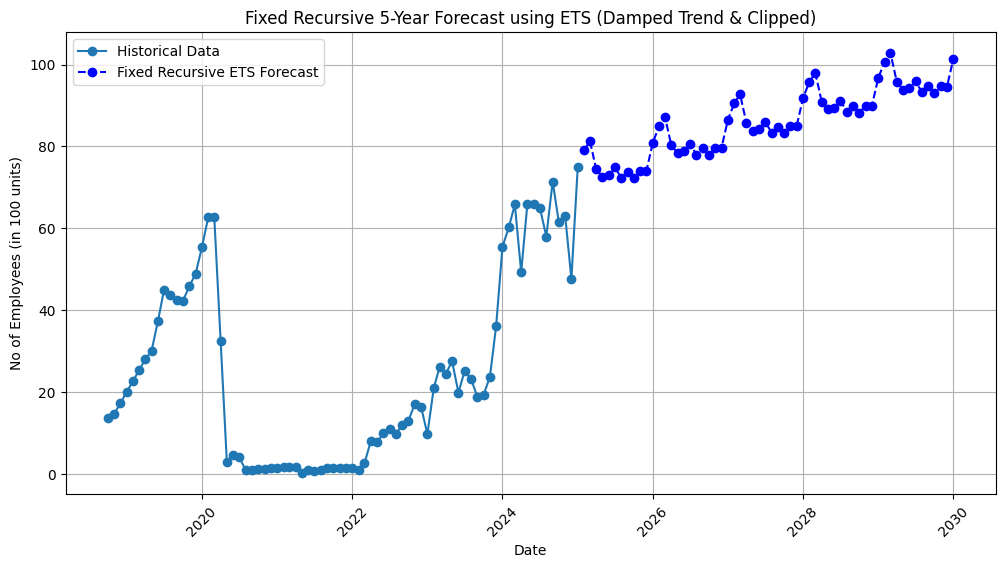

,Date,Recursive Forecasted Employees
2025-02-01,2025-02-01,79.102044
2025-03-01,2025-03-01,81.315570
2025-04-01,2025-04-01,74.379007
2025-05-01,2025-05-01,72.575399
2025-06-01,2025-06-01,73.015293
2025-07-01,2025-07-01,74.864415
2025-08-01,2025-08-01,72.263325
2025-09-01,2025-09-01,73.788945
2025-10-01,2025-10-01,72.167764
2025-11-01,2025-11-01,74.030432


In [ ]:
# Define a more stable ETS model with a damped trend
ets_fixed_model = ExponentialSmoothing(df_site['No of Employees (in 100 units)'], trend='add', seasonal='add', seasonal_periods=12, damped_trend= 'True')
ets_fixed_result = ets_fixed_model.fit()

# Define forecast horizon (60 months for 5 years)
forecast_horizon_ets_fixed = 60

# Generate properly aligned future timestamps
forecast_index_ets_fixed = pd.date_range(start=df_site.index[-1], periods=forecast_horizon_ets_fixed + 1, freq='MS')[1:]

# Generate forecast using the fixed ETS model
forecast_ets_fixed = ets_fixed_result.forecast(steps=forecast_horizon_ets_fixed)

# Apply clipping to remove extreme outliers
forecast_ets_fixed = np.clip(forecast_ets_fixed, a_min=0, a_max=df_site['No of Employees (in 100 units)'].max() * 1.5)

# Convert results to DataFrame
recursive_forecast_ets_fixed_df = pd.DataFrame({"Date": forecast_index_ets_fixed, "Recursive Forecasted Employees": forecast_ets_fixed})

# Step 2: Plot Fixed Recursive ETS Forecast
plt.figure(figsize=(12, 6))
plt.plot(df_site.index, df_site['No of Employees (in 100 units)'], label="Historical Data", marker='o', linestyle='-')
plt.plot(forecast_index_ets_fixed, forecast_ets_fixed, label="Fixed Recursive ETS Forecast", marker='o', linestyle='--', color='blue')
plt.xlabel("Date")
plt.ylabel("No of Employees (in 100 units)")
plt.title("Fixed Recursive 5-Year Forecast using ETS (Damped Trend & Clipped)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()
display(recursive_forecast_ets_fixed_df)


- Problem: Time series models (ETS, SARIMA) need sufficient past observations to learn trends and seasonality properly.

In [ ]:
#USE RECURSIVE FORECASTING FOR EVERY FORECASTING (monthly)
# Average employee counts should match with forecasted employee count (ex: last 2 years avg - 2000, it should match)
#Case -2 - define certain assumptions
#Which model is used ? linear reg ? , polynomial reg ? Xg boost ? lstm ? time series forecasting ?
#Actual vs predicted plots plots
#Test train
#forecasted plots, forecasted data
# CASE -3 (focus on sft served, no of seats ) Take thresholds for 3rd model building.(taking external variables and predict)
#model comparision - why this model is used - why not other model.

## Total Generated Electricity

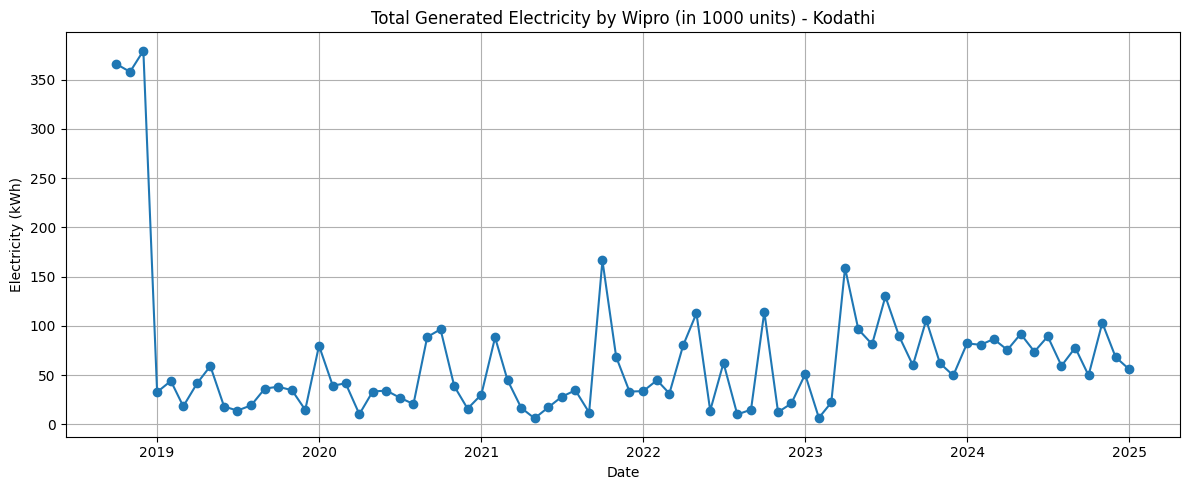

76

In [ ]:
# Focus on the relevant variable for modeling: 'Total Generated Electricity by Wipro'
electricity_series = df_site['Total Generated Electricity (in 1000 units)'].dropna()

# Plot the entire time series
plt.figure(figsize=(12, 5))
plt.plot(electricity_series, marker='o')
plt.title("Total Generated Electricity by Wipro (in 1000 units) - Kodathi")
plt.ylabel("Electricity (kWh)")
plt.xlabel("Date")
plt.grid(True)
plt.tight_layout()
plt.show()

# Display the number of data points
electricity_series.shape[0]


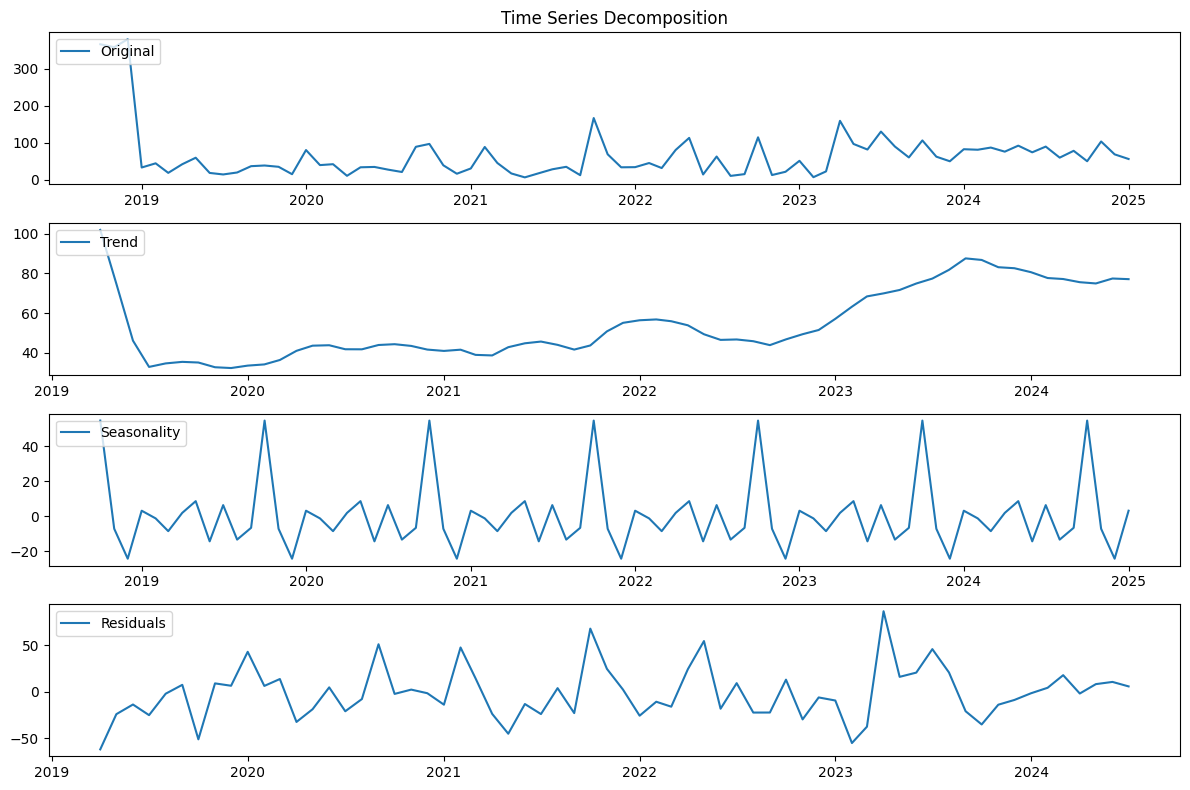

In [ ]:
# Decompose the time series into trend, seasonality, and residuals
decomposition = seasonal_decompose(electricity_series, model='additive', period=12) # Assuming a yearly seasonality (period=12 months)

# Plot the decomposed components
plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(electricity_series, label='Original')
plt.legend(loc='upper left')
plt.title('Time Series Decomposition')

plt.subplot(412)
plt.plot(decomposition.trend, label='Trend')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonality')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(decomposition.resid, label='Residuals')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [ ]:
check_stationarity(electricity_series)

Results of Dickey-Fuller Test:
Test Statistic                -5.789049e+00
p-value                        4.921165e-07
#Lags Used                     0.000000e+00
Number of Observations Used    7.500000e+01
Critical Value (1%)           -3.520713e+00
Critical Value (5%)           -2.900925e+00
Critical Value (10%)          -2.587781e+00
dtype: float64
p-value is less than 0.05, hence the time series is stationary


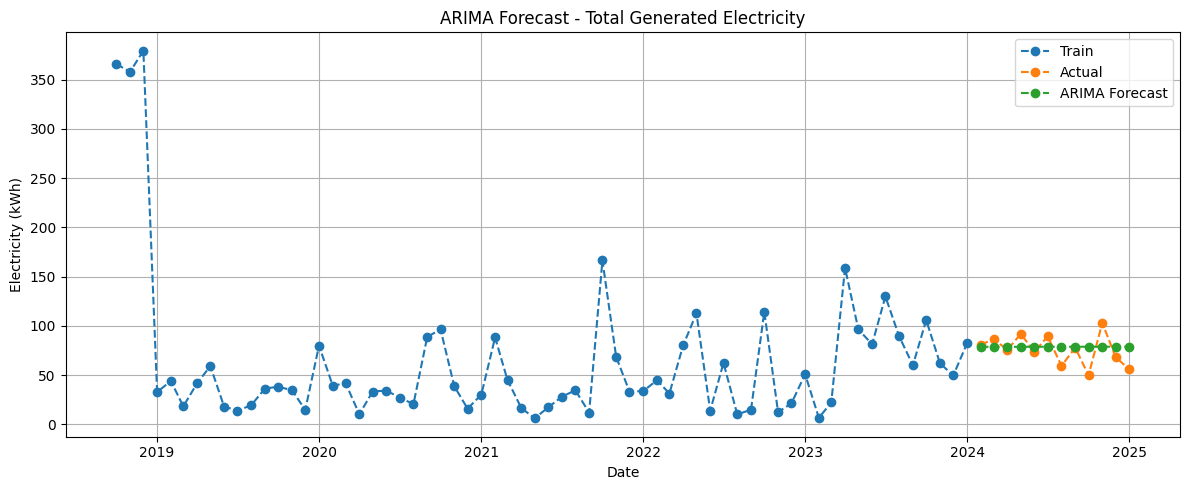

(12.412158504581454,
 np.float64(15.372045056951793),
 np.float64(18.451803708841442))

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Split into training and test sets (last 12 months for testing)
train = electricity_series[:-12]
test = electricity_series[-12:]

# Fit ARIMA model (auto order selection is skipped; using manual order for now)
arima_model = ARIMA(train, order=(1,0,1)).fit()

# Forecast next 12 periods
arima_forecast = arima_model.forecast(steps=12)

# Evaluation Metrics
arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
arima_mape = np.mean(np.abs((test - arima_forecast) / test)) * 100

# Plot actual vs predicted
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label='Train',marker='o', linestyle='--')
plt.plot(test.index, test, label='Actual',marker='o', linestyle='--')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast',marker='o', linestyle='--')
plt.title('ARIMA Forecast - Total Generated Electricity')
plt.ylabel('Electricity (kWh)')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

(arima_mae, arima_rmse, arima_mape)

In [ ]:
import warnings
from statsmodels.tsa.arima.model import ARIMA

# Suppress warnings
warnings.filterwarnings("ignore")

# Grid search for best ARIMA(p,1,q)
results = []
for p in range(4):
    for q in range(4):
        try:
            model = ARIMA(electricity_series, order=(p, d, q))
            fitted = model.fit()
            results.append({
                'p': p,
                'd': d,
                'q': q,
                'AIC': fitted.aic,
                'BIC': fitted.bic
            })
        except:
            continue

# Convert to DataFrame and sort by AIC
results_df = pd.DataFrame(results).sort_values(by='AIC')
display(results_df)
results_df.head()


,p,d,q,AIC,BIC
1,0,1,1,822.993014,827.627990
4,1,1,0,824.198380,828.833356
8,2,1,0,824.670089,831.622553
2,0,1,2,824.798782,831.751247
5,1,1,1,824.818649,831.771113
6,1,1,2,826.029929,835.299881
12,3,1,0,826.538549,835.808501
9,2,1,1,826.545305,835.815257
3,0,1,3,826.740162,836.010115
0,0,1,0,827.534061,829.851549


,p,d,q,AIC,BIC
1,0,1,1,822.993014,827.627990
4,1,1,0,824.198380,828.833356
8,2,1,0,824.670089,831.622553
2,0,1,2,824.798782,831.751247
5,1,1,1,824.818649,831.771113


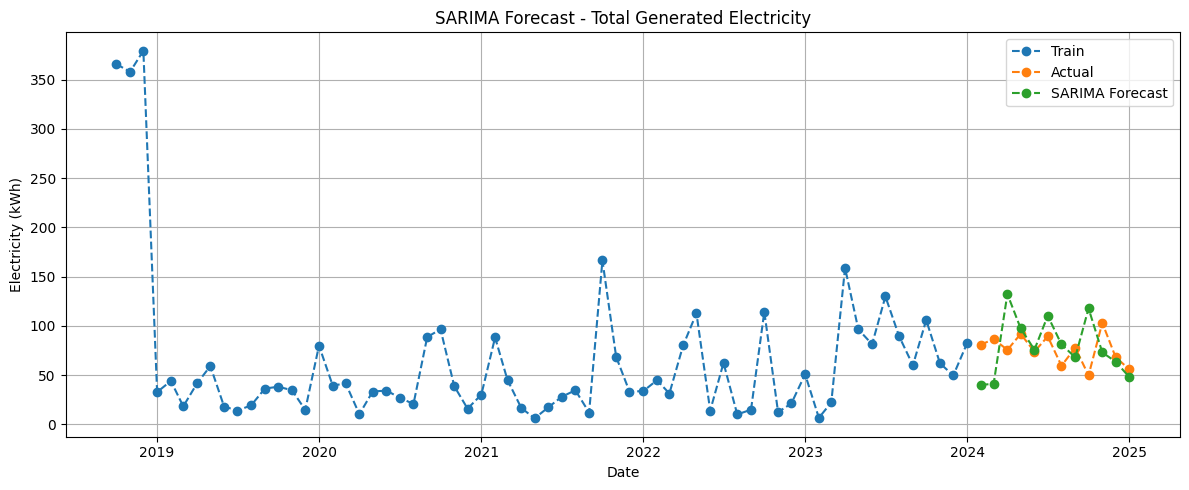

(26.111420190864152,
 np.float64(33.64901590360782),
 np.float64(37.18232585755439))

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit SARIMA model with seasonal order (1,1,1,12) to capture yearly seasonality
sarima_model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12)).fit()

# Forecast next 12 months
sarima_forecast = sarima_model.forecast(steps=12)

# Evaluation Metrics
sarima_mae = mean_absolute_error(test, sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_forecast))
sarima_mape = np.mean(np.abs((test - sarima_forecast) / test)) * 100

# Plot actual vs predicted
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label='Train',marker='o', linestyle='--')
plt.plot(test.index, test, label='Actual',marker='o', linestyle='--')
plt.plot(test.index, sarima_forecast, label='SARIMA Forecast',marker='o', linestyle='--')
plt.title('SARIMA Forecast - Total Generated Electricity')
plt.ylabel('Electricity (kWh)')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

(sarima_mae, sarima_rmse, sarima_mape)


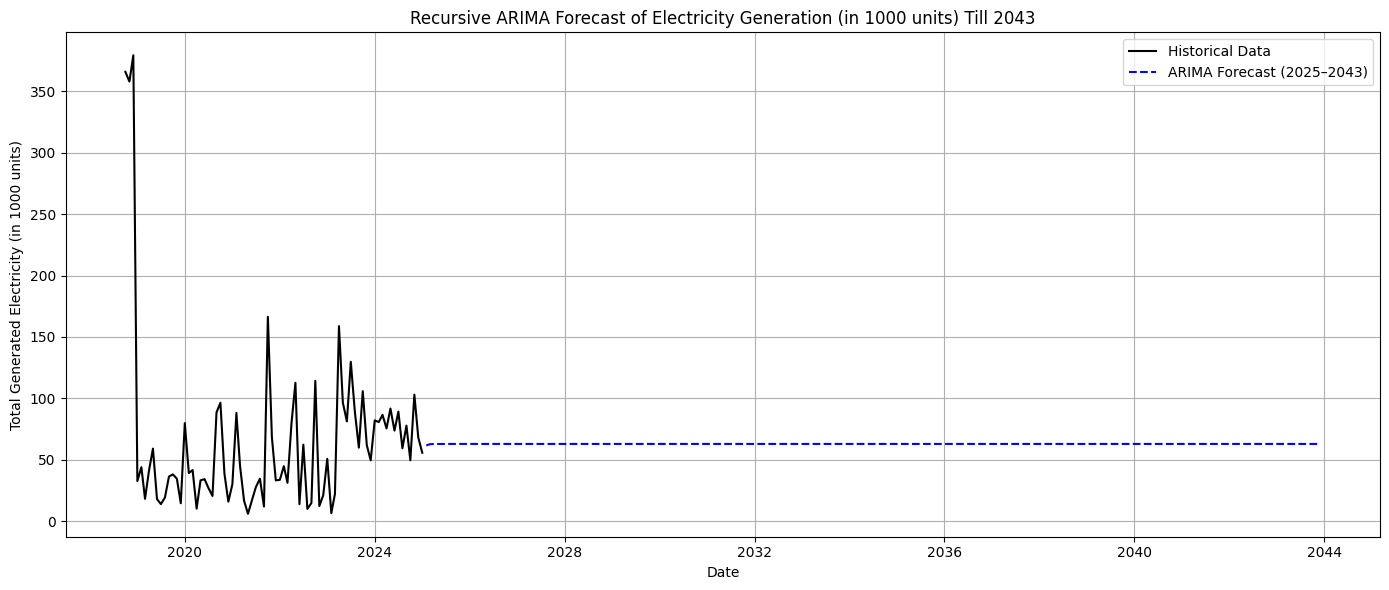

,Date,Forecasted Electricity (in 1000 units)
2025-02-01,2025-02-01,61.70
2025-03-01,2025-03-01,62.72
2025-04-01,2025-04-01,62.90
2025-05-01,2025-05-01,62.93
2025-06-01,2025-06-01,62.93


,Date,Forecasted Electricity (in 1000 units)
2043-08-01,2043-08-01,62.93
2043-09-01,2043-09-01,62.93
2043-10-01,2043-10-01,62.93
2043-11-01,2043-11-01,62.93
2043-12-01,2043-12-01,62.93


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# === Step 2: Prepare Target Series (in 1000 units) ===
y = df_site['Total Generated Electricity (in 1000 units)'].copy()

# === Step 3: Fit ARIMA Model ===
arima_model = ARIMA(y, order=(1, 1, 1))  # Tune if needed
arima_result = arima_model.fit()

# === Step 4: Define Forecast Horizon (till Dec 2043) ===
last_date = y.index[-1]
forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=1),
                               end='2043-12-01',
                               freq='MS')
forecast_steps = len(forecast_index)

# === Step 5: Forecast
arima_forecast = arima_result.forecast(steps=forecast_steps)
arima_forecast.index = forecast_index

# === Step 6: Plot Historical + Forecast ===
plt.figure(figsize=(14, 6))
plt.plot(y, label='Historical Data', color='black')
plt.plot(arima_forecast, label='ARIMA Forecast (2025–2043)', linestyle='--', color='blue')
plt.xlabel('Date')
plt.ylabel('Total Generated Electricity (in 1000 units)')
plt.title('Recursive ARIMA Forecast of Electricity Generation (in 1000 units) Till 2043')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Step 7: Save to CSV ===
forecast_df_arima = pd.DataFrame({
    'Date': arima_forecast.index,
    'Forecasted Electricity (in 1000 units)': arima_forecast.round(2)
})
os.makedirs("forecast_output", exist_ok=True)
forecast_df_arima.to_csv("forecast_output/ARIMA_Electricity_1000Units_Forecast_2025_2043.csv", index=False)

# === Step 8: Display Preview ===
display(forecast_df_arima.head())
display(forecast_df_arima.tail())


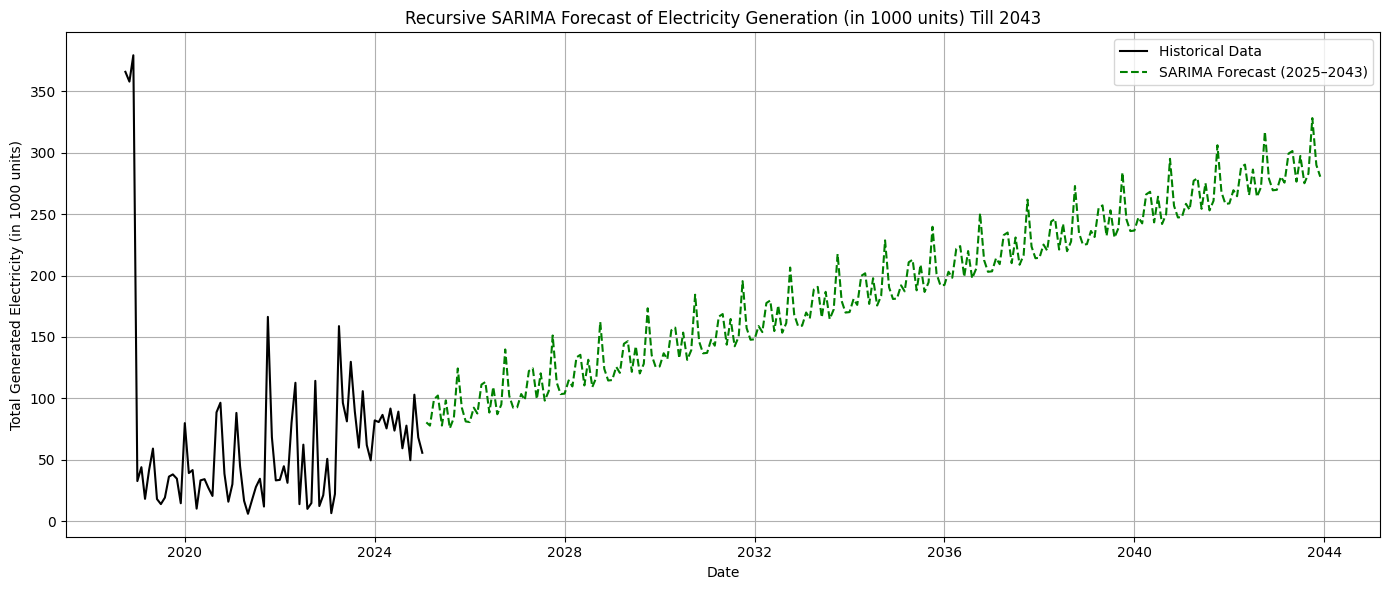

,Date,Forecasted Electricity (in 1000 units)
2025-02-01,2025-02-01,80.47
2025-03-01,2025-03-01,77.84
2025-04-01,2025-04-01,99.24
2025-05-01,2025-05-01,102.33
2025-06-01,2025-06-01,77.89


,Date,Forecasted Electricity (in 1000 units)
2043-08-01,2043-08-01,275.12
2043-09-01,2043-09-01,282.98
2043-10-01,2043-10-01,328.16
2043-11-01,2043-11-01,289.95
2043-12-01,2043-12-01,280.44


In [ ]:
# === Step 3: Fit SARIMA Model ===
sarima_model = SARIMAX(y,
                       order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
sarima_result = sarima_model.fit()

# === Step 4: Define Forecast Timeline ===
last_date = y.index[-1]
forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=1),
                               end='2043-12-01',
                               freq='MS')
forecast_steps = len(forecast_index)

# === Step 5: Forecast Using SARIMA ===
sarima_forecast = sarima_result.forecast(steps=forecast_steps)
sarima_forecast.index = forecast_index

# === Step 6: Plot Historical + Forecast ===
plt.figure(figsize=(14, 6))
plt.plot(y, label='Historical Data', color='black')
plt.plot(sarima_forecast, label='SARIMA Forecast (2025–2043)', linestyle='--', color='green')
plt.xlabel('Date')
plt.ylabel('Total Generated Electricity (in 1000 units)')
plt.title('Recursive SARIMA Forecast of Electricity Generation (in 1000 units) Till 2043')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Step 7: Save to CSV ===
forecast_df_sarima_f = pd.DataFrame({
    'Date': sarima_forecast.index,
    'Forecasted Electricity (in 1000 units)': sarima_forecast.round(2)
})
os.makedirs("forecast_output", exist_ok=True)
forecast_df_sarima_f.to_csv("forecast_output/SARIMA_Electricity_1000Units_Forecast_2025_2043.csv", index=False)

# === Step 8: Display Sample Output ===
display(forecast_df_sarima_f.head())
display(forecast_df_sarima_f.tail())


In [ ]:
# Ensure 'Date' is datetime in both DataFrames
forecast_df_sarima_f['Date'] = pd.to_datetime(forecast_df_sarima_f['Date']).dt.strftime('%Y-%m-%d')
forecast_df_arima_f['Date'] = pd.to_datetime(forecast_df_arima_f['Date']).dt.strftime('%Y-%m-%d')

# Now, the merge should work correctly
combined_forecast_df = pd.merge(
    forecast_df_sarima_f,
    forecast_df_arima_f,
    on='Date',
)

In [ ]:
# Export to Excel
combined_forecast_df.to_excel("combined_forecast_output.xlsx", index=False)